# P&P Trajectory Analysis — LIBERO-PRO

---
GPU Check & Drive Setup
Run every session.

In [1]:
import subprocess, torch
print(subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True).stdout.strip())
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE      = '/content/drive/MyDrive'
CACHE_DIR  = f'{DRIVE}/cs159_jeff/smolvla_colab_cache'
RESULTS_DIR = f'{DRIVE}/cs159_jeff/libero_pro_results'
DB_PATH    = f'{RESULTS_DIR}/rollouts_jeff_2_averages_k5_large_2.db'
HF_HOME = f'{CACHE_DIR}/hf_models'
# SNAPSHOT   = f'{CACHE_DIR}/site_packages.tar.gz'
# LIBERO_TAR = f'{CACHE_DIR}/libero_pro_files.tar.gz'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(HF_HOME, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

os.environ['HF_HOME']               = HF_HOME
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['MUJOCO_GL']             = 'egl'

SNAPSHOT  = f'{CACHE_DIR}/site_packages.tar.gz'
PRO_CACHE = f'{CACHE_DIR}/libero_pro_files.tar.gz'

print(f'\nPackage snapshot: {"FOUND" if os.path.exists(SNAPSHOT) else "NOT FOUND — run Section 3"}')
print(f'LIBERO-PRO cache: {"FOUND" if os.path.exists(PRO_CACHE) else "NOT FOUND — run Section 5b"}')

NVIDIA L4, 23034 MiB
CUDA: True
GPU:  NVIDIA L4
VRAM: 23.7 GB
Mounted at /content/drive

Package snapshot: FOUND
LIBERO-PRO cache: FOUND


Optionally Merge 2 DBs

In [ ]:
# ── Merge two rollout DBs into one, for the analysis notebook's A1 to read ────
# Combines position-perturbation and distractor runs (disjoint suites, unique
# per-episode rollout_ids) into a single merged DB on Drive. Run this BEFORE A1;
# then set A1's DB_PATH to MERGED_DB and proceed with A1/A2/A3/... unchanged.
import sqlite3, os, pandas as pd

DB_A = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_hf_position_perturbs.db'
DB_B = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_hf_distractors.db'
MERGED_DB = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_ppd.db'

SOURCES = [('position_perturbs', DB_A), ('distractors', DB_B)]

# tables to merge, in dependency order (rollouts first; others reference rollout_id)
TABLES = ['rollouts', 'pnp_euler_steps', 'pnp_action_vectors', 'baseline_uncertainty']

if os.path.exists(MERGED_DB):
    os.remove(MERGED_DB)   # rebuild fresh every time this cell runs (idempotent)
merged_con = sqlite3.connect(MERGED_DB)

# ── read each table from each source, concat, write into the merged DB ────────
rollout_id_seen = {}   # rollout_id -> which source tag first saw it (collision check)
table_totals = {}

for table in TABLES:
    frames = []
    for tag, path in SOURCES:
        if not os.path.exists(path):
            print(f'  [{table}] SKIP source "{tag}": file not found ({path})'); continue
        src_con = sqlite3.connect(path)
        try:
            has_table = src_con.execute(
                "SELECT name FROM sqlite_master WHERE type='table' AND name=?", (table,)
            ).fetchone()
            if not has_table:
                print(f'  [{table}] not present in "{tag}", skipping'); continue
            df = pd.read_sql(f'SELECT * FROM {table}', src_con)
            df['_source_db'] = tag
            frames.append(df)
        finally:
            src_con.close()

    if not frames:
        print(f'  [{table}] no data in any source, skipping table entirely'); continue

    # outer-concat so differing schemas (e.g. older DB missing a_std_vec/bc_vec
    # columns added later) don't crash — missing cells become NaN
    merged = pd.concat(frames, ignore_index=True, sort=False)

    # collision check on rollout_id (should never happen — uuid per episode —
    # but verify rather than assume)
    if 'rollout_id' in merged.columns:
        dup = merged['rollout_id'][merged['rollout_id'].duplicated()].unique()
        if len(dup):
            print(f'  [{table}] ⚠ {len(dup)} DUPLICATE rollout_id(s) across sources — '
                  f'first few: {list(dup[:5])}')
        for rid, tag in zip(merged['rollout_id'], merged['_source_db']):
            rollout_id_seen.setdefault(rid, tag)

    merged.to_sql(table, merged_con, if_exists='replace', index=False)
    table_totals[table] = len(merged)
    print(f'  [{table}] merged {len(merged)} rows '
          f'({" + ".join(f"{tag}:{len(f)}" for (tag,_),f in zip(SOURCES, frames))})')

merged_con.commit()

# ── sanity summary ─────────────────────────────────────────────────────────────
print(f'\nMerged DB written: {MERGED_DB}')
if 'rollouts' in table_totals:
    r = pd.read_sql('SELECT pnp_mode, suite, COUNT(*) n FROM rollouts GROUP BY pnp_mode, suite', merged_con)
    print(f'\n{len(r)} (pnp_mode, suite) combinations in merged rollouts:')
    print(r.groupby('pnp_mode')['n'].sum().to_string())
    print(f'\nSuites present: {sorted(pd.read_sql("SELECT DISTINCT suite FROM rollouts", merged_con)["suite"])}')

merged_con.close()
print(f'\n>>> Point A1 at:  DB_PATH = {MERGED_DB!r}')

  [rollouts] merged 6600 rows (position_perturbs:4500 + distractors:2100)
  [pnp_euler_steps] ⚠ 6600 DUPLICATE rollout_id(s) across sources — first few: ['1d718464-2510-4782-955e-887b69099619', '6f9767ad-2ebf-45df-b9f8-5c7d7e85f366', '6de3f7d4-c8a3-41e9-a2f1-1cf7fef5af17', 'b39a1bad-6c12-4705-9c26-845e5ab6a09b', '174cdb8d-681d-4708-9fc3-0567944972d8']
  [pnp_euler_steps] merged 62352 rows (position_perturbs:49142 + distractors:13210)
  [pnp_action_vectors] ⚠ 6600 DUPLICATE rollout_id(s) across sources — first few: ['1d718464-2510-4782-955e-887b69099619', '6f9767ad-2ebf-45df-b9f8-5c7d7e85f366', '6de3f7d4-c8a3-41e9-a2f1-1cf7fef5af17', 'b39a1bad-6c12-4705-9c26-845e5ab6a09b', '174cdb8d-681d-4708-9fc3-0567944972d8']
  [pnp_action_vectors] merged 62352 rows (position_perturbs:49142 + distractors:13210)
  [baseline_uncertainty] not present in "position_perturbs", skipping
  [baseline_uncertainty] not present in "distractors", skipping
  [baseline_uncertainty] no data in any source, skipping t

In [2]:
# ── Merge uncertainty (fixed) + refinement (last & avg) DBs for A1 to read ─────
# UNCERTAINTY_DB supplies ONLY pnp_mode=='uncertainty' rows (the corrected
# baseline, post init-sourcing fix). Each REFINEMENT_DB supplies ONLY
# pnp_mode in ('both','both_avg') rows — any stale/old 'uncertainty' rows those
# files might also contain are deliberately EXCLUDED, so the corrected baseline
# is never mixed with a possibly-uncorrected one. Run BEFORE A1; then point A1's
# DB_PATH at MERGED_DB and proceed with A1/A2/A3/... unchanged.
import sqlite3, os, pandas as pd

UNCERTAINTY_DB = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_uncertainty_fix.db'
REFINEMENT_DBS = [
    '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_hf_tasks_swap10.db',
    '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_hf_swaps_no10.db',
    '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_ppd.db',
]
MERGED_DB = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_merged.db'

# (tag, path, allowed pnp_modes for the `rollouts` table)
SOURCES = [('uncertainty_fix', UNCERTAINTY_DB, ['uncertainty'])] + [
    (f'refine_{i+1}_{os.path.basename(p).replace("rollouts_enlarged_","").replace(".db","")}',
     p, ['both', 'both_avg'])
    for i, p in enumerate(REFINEMENT_DBS)
]

TABLES = ['rollouts', 'pnp_euler_steps', 'pnp_action_vectors', 'baseline_uncertainty']

if os.path.exists(MERGED_DB):
    os.remove(MERGED_DB)
merged_con = sqlite3.connect(MERGED_DB)

table_frames = {t: [] for t in TABLES}   # accumulate across sources, write once at the end

for tag, path, allowed_modes in SOURCES:
    if not os.path.exists(path):
        print(f'SKIP source "{tag}": file not found ({path})'); continue
    src_con = sqlite3.connect(path)

    # ── rollouts: filter to allowed_modes for THIS source ──
    has_rollouts = src_con.execute(
        "SELECT name FROM sqlite_master WHERE type='table' AND name='rollouts'").fetchone()
    if not has_rollouts:
        print(f'[{tag}] no rollouts table, skipping source entirely'); src_con.close(); continue

    placeholders = ','.join('?' * len(allowed_modes))
    roll = pd.read_sql(
        f'SELECT * FROM rollouts WHERE pnp_mode IN ({placeholders})', src_con, params=allowed_modes)
    roll['_source_db'] = tag
    kept_ids = set(roll['rollout_id'])
    table_frames['rollouts'].append(roll)
    print(f'[{tag}] rollouts: kept {len(roll)} rows with pnp_mode in {allowed_modes} '
          f'(source file may have had other modes — excluded)')

    # ── dependent tables: keep only rows whose rollout_id survived the mode filter ──
    for table in TABLES[1:]:
        has_t = src_con.execute(
            "SELECT name FROM sqlite_master WHERE type='table' AND name=?", (table,)).fetchone()
        if not has_t:
            continue
        df = pd.read_sql(f'SELECT * FROM {table}', src_con)
        if 'rollout_id' in df.columns:
            df = df[df['rollout_id'].isin(kept_ids)]
        df['_source_db'] = tag
        if len(df):
            table_frames[table].append(df)

    src_con.close()

# ── concat across sources per table, write into merged DB ────────────────────
print()
for table in TABLES:
    frames = table_frames[table]
    if not frames:
        print(f'[{table}] no data from any source, skipping table'); continue
    merged = pd.concat(frames, ignore_index=True, sort=False)   # outer concat: schema-tolerant

    if 'rollout_id' in merged.columns:
        dup = merged['rollout_id'][merged['rollout_id'].duplicated()].unique()
        if len(dup):
            print(f'[{table}] ⚠ {len(dup)} DUPLICATE rollout_id(s) across sources — '
                  f'first few: {list(dup[:5])}')

    merged.to_sql(table, merged_con, if_exists='replace', index=False)
    print(f'[{table}] merged {len(merged)} total rows')

merged_con.commit()

# ── sanity summary ─────────────────────────────────────────────────────────────
print(f'\nMerged DB written: {MERGED_DB}')
r = pd.read_sql('SELECT pnp_mode, _source_db, COUNT(*) n FROM rollouts '
                'GROUP BY pnp_mode, _source_db', merged_con)
print('\nRows by pnp_mode x source:')
print(r.to_string(index=False))
print('\nTotal by pnp_mode:')
print(r.groupby('pnp_mode')['n'].sum().to_string())
print(f'\nSuites present: {sorted(pd.read_sql("SELECT DISTINCT suite FROM rollouts", merged_con)["suite"])}')

merged_con.close()
print(f'\n>>> Point A1 at:  DB_PATH = {MERGED_DB!r}')

[uncertainty_fix] rollouts: kept 3700 rows with pnp_mode in ['uncertainty'] (source file may have had other modes — excluded)
[refine_1_hf_tasks_swap10] rollouts: kept 1500 rows with pnp_mode in ['both', 'both_avg'] (source file may have had other modes — excluded)
[refine_2_hf_swaps_no10] rollouts: kept 1500 rows with pnp_mode in ['both', 'both_avg'] (source file may have had other modes — excluded)
[refine_3_ppd] rollouts: kept 4400 rows with pnp_mode in ['both', 'both_avg'] (source file may have had other modes — excluded)

[rollouts] merged 11100 total rows
[pnp_euler_steps] ⚠ 11100 DUPLICATE rollout_id(s) across sources — first few: ['0e7842f4-f246-4265-abcc-96e800a5a5b7', 'ead013e7-0058-4308-81e4-aa67c76e7bca', '79ae8a0e-be9e-414c-8f95-1ed9ffddc15f', '6273ccd4-eccd-4f29-b88a-d5647ab35ed5', '871cf081-fab5-424f-8b40-6f5464610e3a']
[pnp_euler_steps] merged 122608 total rows
[pnp_action_vectors] ⚠ 11100 DUPLICATE rollout_id(s) across sources — first few: ['0e7842f4-f246-4265-abcc-96e

In [3]:
# ── Diagnose the merged DB: (1) the uncertainty-vs-refinement count gap, and ───
# (2) whether the flagged duplicate rollout_ids are true redundant copies.
# Read-only against the already-written MERGED_DB. Run after merge_dbs_cell.py.
import sqlite3, pandas as pd
MERGED_DB = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_merged.db'
KEYS = ['suite', 'task_idx', 'episode_idx', 'init_state_hash']

con = sqlite3.connect(MERGED_DB)
r = pd.read_sql('SELECT * FROM rollouts', con)
con.close()

# ── PART 1: are the duplicate rollout_ids TRUE redundant copies? ──────────────
dup_ids = r['rollout_id'][r['rollout_id'].duplicated()].unique()
print(f'=== PART 1: {len(dup_ids)} duplicate rollout_id(s) ===')
if len(dup_ids):
    dsub = r[r['rollout_id'].isin(dup_ids)]
    # for each dup id, are ALL its rows identical on the key content columns?
    check_cols = KEYS + ['success', 'pnp_mode']
    identical = dsub.groupby('rollout_id')[check_cols].nunique().eq(1).all(axis=1)
    print(f'  {identical.sum()}/{len(identical)} duplicate ids are TRUE exact copies '
          f'(same suite/task/episode/hash/success/mode)')
    if not identical.all():
        print('  Non-identical duplicates (different content under the same id — investigate!):')
        print(dsub[dsub['rollout_id'].isin(identical[~identical].index)]
              [['rollout_id','suite','task_idx','episode_idx','success','pnp_mode','_source_db']]
              .to_string(index=False))
    # which source pairs are responsible?
    src_pairs = (dsub.groupby('rollout_id')['_source_db']
                 .apply(lambda s: tuple(sorted(s))).value_counts())
    print('\n  Duplicate rollout_ids by (source_a, source_b) pair:')
    print(src_pairs.to_string())
    print('\n  RECOMMENDATION: these look like the same underlying rows counted twice '
          '(one source is a superset/copy of another). Drop one side rather than keep both.')

# ── PART 2: key-level gap between uncertainty and refinement (the "50") ──────
print(f'\n=== PART 2: pairing-key gap between uncertainty and refinement ===')
r_dedup = r.drop_duplicates(subset='rollout_id', keep='first')   # avoid double-counting in this check

unc = r_dedup[r_dedup.pnp_mode == 'uncertainty']
ref = r_dedup[r_dedup.pnp_mode.isin(['both', 'both_avg'])]

unc_keys = set(map(tuple, unc[KEYS].values))
# a key counts as "present in refinement" if EITHER both or both_avg has it
ref_keys = set(map(tuple, ref[KEYS].values))

only_unc = unc_keys - ref_keys
only_ref = ref_keys - unc_keys
print(f'  distinct episode-keys in uncertainty : {len(unc_keys)}')
print(f'  distinct episode-keys in refinement   : {len(ref_keys)}')
print(f'  keys in UNCERTAINTY only (missing from refinement): {len(only_unc)}')
print(f'  keys in REFINEMENT only (missing from uncertainty): {len(only_ref)}')

def show_by_suite(keys, label):
    if not keys: return
    df = pd.DataFrame(list(keys), columns=KEYS)
    print(f'\n  {label} — breakdown by (suite, task_idx):')
    print(df.groupby(['suite','task_idx']).size().to_string())

show_by_suite(only_unc, 'Uncertainty-only keys')
show_by_suite(only_ref, 'Refinement-only keys')

# ── PART 3: recommended action ────────────────────────────────────────────────
print(f'\n=== PART 3: recommendation ===')
if only_unc or only_ref:
    print(f'  To keep the paired analysis valid, restrict to the INTERSECTION of keys '
          f'({len(unc_keys & ref_keys)} episodes) — dropping {len(only_unc)} uncertainty-only '
          f'and {len(only_ref)} refinement-only rows. See the filter snippet below.')
else:
    print('  No gap after dedup — uncertainty and refinement keys match exactly.')

=== PART 1: 0 duplicate rollout_id(s) ===

=== PART 2: pairing-key gap between uncertainty and refinement ===
  distinct episode-keys in uncertainty : 3700
  distinct episode-keys in refinement   : 3700
  keys in UNCERTAINTY only (missing from refinement): 0
  keys in REFINEMENT only (missing from uncertainty): 0

=== PART 3: recommendation ===
  No gap after dedup — uncertainty and refinement keys match exactly.


---
# A: Uncertainty and Success Rate Data

## A1. Load & Summarise Database

In [7]:
import sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Connect (works whether we are continuing this session or loading a saved DB)
RESULTS_DIR = '/content/drive/MyDrive/cs159_jeff/libero_pro_results'
DB_PATH     = f'{RESULTS_DIR}/rollouts_enlarged_merged.db'
con_a       = sqlite3.connect(DB_PATH)
con_a.row_factory = sqlite3.Row

rollouts = pd.read_sql('SELECT * FROM rollouts', con_a)
steps_df = pd.read_sql('SELECT * FROM pnp_euler_steps', con_a)

# Parse JSON step indices
def _parse_idx(s):
    try:    return json.loads(s)
    except: return s
rollouts['step_indices_parsed'] = rollouts['pnp_step_indices'].map(_parse_idx)

# Phase splits
baseline = rollouts[rollouts.pnp_enabled == 0].copy()
pnp_all  = rollouts[rollouts.pnp_enabled == 1].copy()
phase2   = pnp_all[pnp_all['pnp_mode'] == 'uncertainty'].copy()
phase3   = pnp_all[pnp_all['pnp_mode'] == 'both'].copy()

steps_p2 = steps_df[steps_df['rollout_id'].isin(set(phase2['rollout_id']))].copy()
steps_p3 = steps_df[steps_df['rollout_id'].isin(set(phase3['rollout_id']))].copy()

# Suite type annotation
def suite_type(s):
    if 'temp_' in s:  return 'position_perturb'
    if '_with_' in s: return 'distractor'
    return 'other'
for df in [rollouts, baseline, pnp_all, phase2, phase3]:
    df['suite_type'] = df['suite'].map(suite_type)

print(f'Total rollouts: {len(rollouts)}')
print(f'  Baseline (phase 1): {len(baseline)}')
print(f'  Uncertainty only (phase 2): {len(phase2)}')
print(f'  Refinement (phase 3): {len(phase3)}')
print(f'  Euler steps rows: {len(steps_df)}')
print()
print('Suites in DB:', sorted(rollouts.suite.unique().tolist()))
print()
print('Baseline SR per suite:')
for suite, grp in baseline.groupby('suite'):
    print(f'  {suite:<45} {grp.success.mean():.1%}  (n={len(grp)})')

Total rollouts: 11100
  Baseline (phase 1): 0
  Uncertainty only (phase 2): 3700
  Refinement (phase 3): 3700
  Euler steps rows: 122608

Suites in DB: ['libero_10_swap', 'libero_goal_swap', 'libero_goal_task', 'libero_goal_with_milk', 'libero_goal_with_yellow_book', 'libero_object_swap', 'libero_object_task', 'libero_object_temp_x0.1', 'libero_object_temp_x0.2', 'libero_object_temp_x0.3', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_object_temp_y0.3', 'libero_object_with_mug', 'libero_spatial_swap', 'libero_spatial_with_milk']

Baseline SR per suite:


In [8]:
# ── Ground-truth DB read, bypassing A1 entirely ──────────────────────────────
# Run this in a FRESH cell. It opens the file directly, prints the exact path,
# row count, and mode breakdown, so we can see what's really on disk.
import sqlite3, pandas as pd, os

PATH = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_merged.db'
print('path        :', PATH)
print('exists      :', os.path.exists(PATH))
print('size (MB)   :', round(os.path.getsize(PATH)/1e6, 2) if os.path.exists(PATH) else 'MISSING')

con = sqlite3.connect(PATH)
# tables present
tabs = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)['name'].tolist()
print('tables      :', tabs)

n = pd.read_sql('SELECT COUNT(*) c FROM rollouts', con)['c'][0]
print('rollouts    :', n)

br = pd.read_sql(
    'SELECT pnp_enabled, pnp_mode, COUNT(*) n, ROUND(AVG(success)*100,1) sr '
    'FROM rollouts GROUP BY pnp_enabled, pnp_mode', con)
print('\nbreakdown:')
print(br.to_string(index=False))

# distinct pnp_num_iterations too (k5?) and any distinct DB_PATH-relevant flags
if n:
    it = pd.read_sql('SELECT DISTINCT pnp_num_iterations FROM rollouts', con)['pnp_num_iterations'].tolist()
    print('\npnp_num_iterations values:', it)
con.close()

path        : /content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_merged.db
exists      : True
size (MB)   : 85.8
tables      : ['rollouts', 'pnp_euler_steps', 'pnp_action_vectors']
rollouts    : 11100

breakdown:
 pnp_enabled    pnp_mode    n   sr
           1        both 3700 29.0
           1    both_avg 3700 29.8
           1 uncertainty 3700 30.1

pnp_num_iterations values: [10]


# If both average and last-prediction refinement are logged, choose one as baseline

In [13]:
# ── Toggle: which refinement variant do A2/A3/etc. analyze? ────────────────────
# Redefines `phase3` (+ steps_p3) to the chosen refinement variant, based on how
# the run was tagged in pnp_mode. Place this cell RIGHT AFTER A1 (the load cell);
# every later cell reads `phase3`, so they follow this choice automatically.
#
#   REFINE_VARIANT = 'last'  -> last-prediction refinement   (pnp_mode == 'both')
#   REFINE_VARIANT = 'avg'   -> averaged refinement          (pnp_mode == 'both_avg')
#   REFINE_VARIANT = 'auto'  -> pick 'avg' if present, else 'last'
REFINE_VARIANT = 'avg'

# tag mapping (edit here if your averaged run used a different tag string)
_VARIANT_TAG = {'last': 'both', 'avg': 'both_avg'}

# what refinement tags actually exist in this DB?
_present = sorted(pnp_all['pnp_mode'].unique().tolist())
_refine_tags = [t for t in _present if t not in ('uncertainty',)]
print(f"pnp_mode values in DB: {_present}")
print(f"refinement-type tags present: {_refine_tags}")

if REFINE_VARIANT == 'auto':
    REFINE_VARIANT = 'avg' if _VARIANT_TAG['avg'] in _present else 'last'
    print(f"auto -> '{REFINE_VARIANT}'")

if REFINE_VARIANT not in _VARIANT_TAG:
    raise ValueError(f"REFINE_VARIANT must be one of {list(_VARIANT_TAG)} or 'auto'.")
_tag = _VARIANT_TAG[REFINE_VARIANT]

if _tag not in _present:
    msg = (f"Requested variant '{REFINE_VARIANT}' (pnp_mode='{_tag}') is NOT in this DB.\n"
           f"Available refinement tags: {_refine_tags}.")
    if _tag == 'both_avg' and 'both' in _present:
        msg += ("\nThis DB tags refinement only as 'both'. If it was produced by a SINGLE "
                "averaged run, the rows are averaged but indistinguishable from last-prediction; "
                "use REFINE_VARIANT='last' to select them (they are the only 'both' rows). "
                "Averaged and last-prediction can only be separated if the run tagged them "
                "differently (e.g. 'both_avg').")
    raise SystemExit(msg)

# reassign phase3 (+ its euler steps) to the chosen variant; downstream cells follow
phase3 = pnp_all[pnp_all['pnp_mode'] == _tag].copy()
steps_p3 = steps_df[steps_df['rollout_id'].isin(set(phase3['rollout_id']))].copy()

print(f"\n>>> Analyzing refinement variant: '{REFINE_VARIANT}' (pnp_mode == '{_tag}')")
print(f"    phase3: {len(phase3)} rollouts, SR {phase3['success'].mean()*100:.2f}%")
print("    A2/A3/A4/A5 will now use THIS variant as the refinement pass.")

pnp_mode values in DB: ['both', 'both_avg', 'uncertainty']
refinement-type tags present: ['both', 'both_avg']

>>> Analyzing refinement variant: 'avg' (pnp_mode == 'both_avg')
    phase3: 3700 rollouts, SR 29.84%
    A2/A3/A4/A5 will now use THIS variant as the refinement pass.


## A2. Phase Comparison — Uncertainty vs. Refinement

In [ ]:
# ── Build a baseline from the uncertainty (no-op) pass, then re-pair ────────────
# This DB has 600 'uncertainty' + 600 'both' rollouts and NO pnp_enabled==0 rows.
# Under the verified no-op, uncertainty-mode executes the SAME trajectory as vanilla,
# so its `success` equals the vanilla baseline success. We therefore use the
# uncertainty pass as the baseline for all paired analyses. No re-running required.
#
# Run this AFTER cell A1 (needs `rollouts`, `phase2`, `phase3`, pandas as pd).

# 1) Baseline = the uncertainty (measure-only) pass, relabeled.
baseline = phase2.copy()
baseline['pnp_enabled'] = 0          # so downstream code that keys on this still works
print(f'Baseline built from uncertainty pass: {len(baseline)} rows '
      f'(SR = {baseline.success.mean():.1%})')

# 2) Sanity: pairing keys should now overlap between baseline and refinement.
keys = ['suite','task_idx','episode_idx','init_state_hash']
kb = set(map(tuple, baseline[keys].values))
kp = set(map(tuple, phase3[keys].values))
print(f"Refinement ('both') rows: {len(phase3)} (SR = {phase3.success.mean():.1%})")
print(f'Overlapping paired keys: {len(kb & kp)} '
      f'(expect ≈ min({len(kb)}, {len(kp)}) if seeds match)')

# 3) Duplicate-key guard: the merge in A3 is many-to-many if keys repeat, which would
#    inflate counts. Confirm each (suite,task,ep,hash) is unique within each phase.
for name, df in [('baseline', baseline), ('refinement', phase3)]:
    dup = df.duplicated(subset=keys).sum()
    if dup:
        print(f'  ⚠ {name}: {dup} duplicate keys — dedup before pairing '
              f'(keep most-recent by timestamp).')
        # keep most-recent per key
        df.sort_values('timestamp').drop_duplicates(subset=keys, keep='last', inplace=True)
if len(kb & kp) == 0:
    print('  ⚠ Still no overlap — seeds/init hashes differ between passes; pairing not possible.')
else:
    print('✓ Ready: re-run cells A2–A5 as-is; they will pair baseline ↔ refinement correctly.')

Baseline built from uncertainty pass: 2200 rows (SR = 45.5%)
Refinement ('both') rows: 2200 (SR = 45.6%)
Overlapping paired keys: 2200 (expect ≈ min(2200, 2200) if seeds match)
✓ Ready: re-run cells A2–A5 as-is; they will pair baseline ↔ refinement correctly.


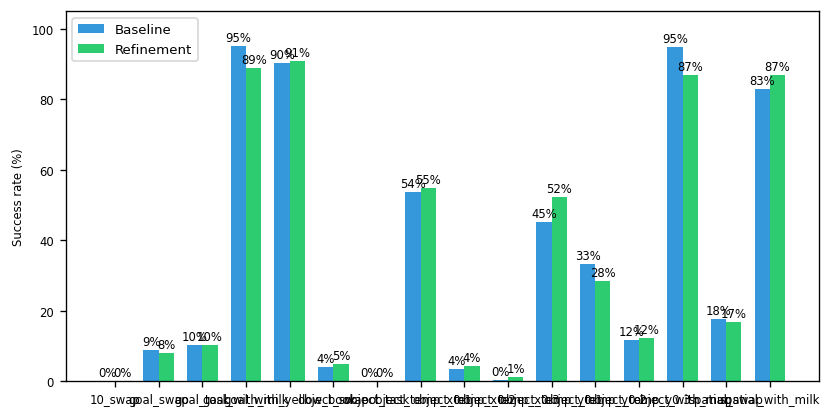

Aggregate SR over all episodes:
  baseline (n=0):           nan%
  uncertainty only (n=3700):     30.05%  (Δ +nan pp vs baseline)
  refinement (n=3700):           29.84%  (Δ +nan pp vs baseline)


In [14]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3 (RSS requirement)
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams.update({
    'font.size':        7,    # base — affects tick labels
    'axes.labelsize':   7,    # x/y axis labels
    'xtick.labelsize':  7,    # x tick labels
    'ytick.labelsize':  7,    # y tick labels
    'legend.fontsize':  70,    # legend only — bigger than the rest
})

if len(phase2) == 0 and len(phase3) == 0:
    print('No P&P data yet — run phases 2 and 3 first.')
else:
    suites = sorted(set(
        baseline['suite'].tolist() + phase2['suite'].tolist() + phase3['suite'].tolist()
    ))
    x  = np.arange(len(suites))
    w  = 0.35
    sr_base = baseline.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr_p2   = phase2.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr_p3   = phase3.groupby('suite')['success'].mean().reindex(suites).fillna(0)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    b2 = ax.bar(x - w/2, sr_p2 * 100, width=w, label='Baseline', color='#3498db')
    b3 = ax.bar(x + w/2, sr_p3 * 100, width=w, label='Refinement',       color='#2ecc71')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=0, ha='center')
    ax.set_ylabel('Success rate (%)')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8)
    for bars_patch, vals in [(b2, sr_p2), (b3, sr_p3)]:
        for bar, v in zip(bars_patch, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v*100:.0f}%', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/phase_comparison.png', dpi=150)
    plt.show()

    # ── aggregate success-rate change across all episodes ──
    base_sr = baseline['success'].mean()
    p2_sr   = phase2['success'].mean()
    p3_sr   = phase3['success'].mean()
    print(f'Aggregate SR over all episodes:')
    print(f'  baseline (n={len(baseline)}):           {base_sr*100:.2f}%')
    print(f'  uncertainty only (n={len(phase2)}):     {p2_sr*100:.2f}%  '
          f'(Δ {(p2_sr-base_sr)*100:+.2f} pp vs baseline)')
    print(f'  refinement (n={len(phase3)}):           {p3_sr*100:.2f}%  '
          f'(Δ {(p3_sr-base_sr)*100:+.2f} pp vs baseline)')

## A3. Paired Episode Transition Analysis
For each episode, compares baseline outcome to P&P outcome (same `init_state_hash`).

Paired episodes: 600

Overall transition counts:
transition
failure → failure       257
success → success       243
success → failure  ✗     51
failure → success  ✓     49

Baseline SR:   49.0%
Refinement SR: 48.7%

Per-suite transitions:
  libero_goal_with_yellow_book               base=94%  pnp=90%  F→S=3  S→F=7
  libero_object_temp_x0.1                    base=45%  pnp=48%  F→S=15  S→F=12
  libero_object_temp_x0.2                    base=4%  pnp=5%  F→S=2  S→F=1
  libero_object_temp_y0.1                    base=48%  pnp=43%  F→S=10  S→F=15
  libero_object_temp_y0.2                    base=24%  pnp=30%  F→S=12  S→F=6
  libero_spatial_with_milk                   base=79%  pnp=76%  F→S=7  S→F=10


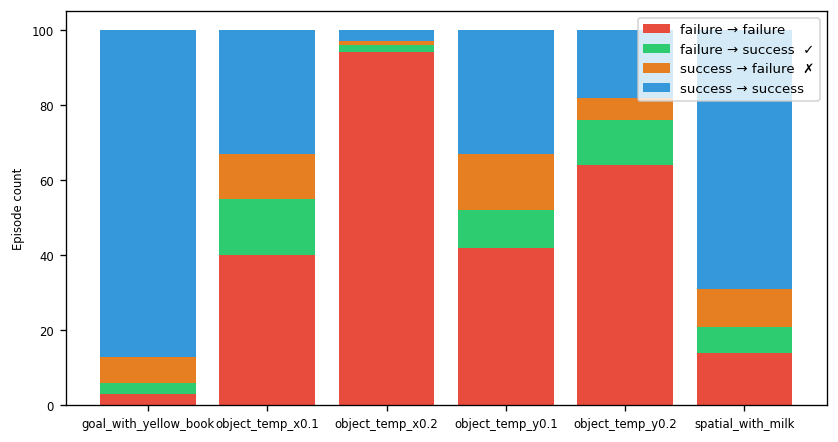

In [ ]:
matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3 (RSS requirement)
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams.update({
    'font.size':        7,    # base — affects tick labels
    'axes.labelsize':   7,    # x/y axis labels
    'xtick.labelsize':  7,    # x tick labels
    'ytick.labelsize':  7,    # y tick labels
    'legend.fontsize':  60,    # legend only — bigger than the rest
})

ax.legend(
    fontsize=9,
    borderpad=1.0,
    labelspacing=0.6,
    handletextpad=0.6,
    handlelength=2.5,
    handleheight=1.2,
    framealpha=0.9,    # slightly transparent background
    edgecolor='gray',  # subtle border
)

if len(phase3) == 0:
    print('No Phase 3 data yet.')
else:
    # Pair baseline ↔ phase3 on (suite, task_idx, episode_idx, init_state_hash)
    b_key = baseline[['suite','task_idx','episode_idx','init_state_hash','success']].copy()
    b_key = b_key.rename(columns={'success': 'success_baseline'})
    p_key = phase3[['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']].copy()
    p_key = p_key.rename(columns={'success': 'success_pnp'})

    paired = b_key.merge(p_key, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')
    print(f'Paired episodes: {len(paired)}')

    def _transition(row):
        b, p = int(row['success_baseline']), int(row['success_pnp'])
        if b == 1 and p == 1: return 'success → success'
        if b == 0 and p == 1: return 'failure → success  ✓'
        if b == 1 and p == 0: return 'success → failure  ✗'
        return 'failure → failure'

    paired['transition'] = paired.apply(_transition, axis=1)

    # Global counts
    counts = paired['transition'].value_counts()
    print('\nOverall transition counts:')
    print(counts.to_string())
    print(f'\nBaseline SR:   {paired.success_baseline.mean():.1%}')
    print(f'Refinement SR: {paired.success_pnp.mean():.1%}')

    # Per-suite table
    print('\nPer-suite transitions:')
    for suite, grp in paired.groupby('suite'):
        tc = grp['transition'].value_counts()
        f2s = tc.get('failure → success  ✓', 0)
        s2f = tc.get('success → failure  ✗', 0)
        print(f'  {suite:<42} '
              f'base={grp.success_baseline.mean():.0%}  '
              f'pnp={grp.success_pnp.mean():.0%}  '
              f'F→S={f2s}  S→F={s2f}')

    # Transition chart per suite
    suites = sorted(paired['suite'].unique())
    cats   = ['failure → failure', 'failure → success  ✓',
              'success → failure  ✗', 'success → success']
    cat_colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

    fig, ax = plt.subplots(figsize=(7, 3.7))
    bottom = np.zeros(len(suites))
    for cat, color in zip(cats, cat_colors):
        vals = [
            paired[paired.suite == s]['transition'].value_counts().get(cat, 0)
            for s in suites
        ]
        ax.bar(range(len(suites)), vals, bottom=bottom, label=cat, color=color)
        bottom += np.array(vals, dtype=float)
    ax.set_xticks(range(len(suites)))
    ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=0, ha='center')
    ax.set_ylabel('Episode count')
    # ax.set_title('Baseline → Refinement outcome transitions per suite')
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/transition_chart.png', dpi=150)
    plt.show()

## A4. Threshold Window Sweep

No pnp_enabled==0 rows; using uncertainty pass as baseline (3700 rows).
Total paired episodes: 3700
Overall baseline SR:   0.301


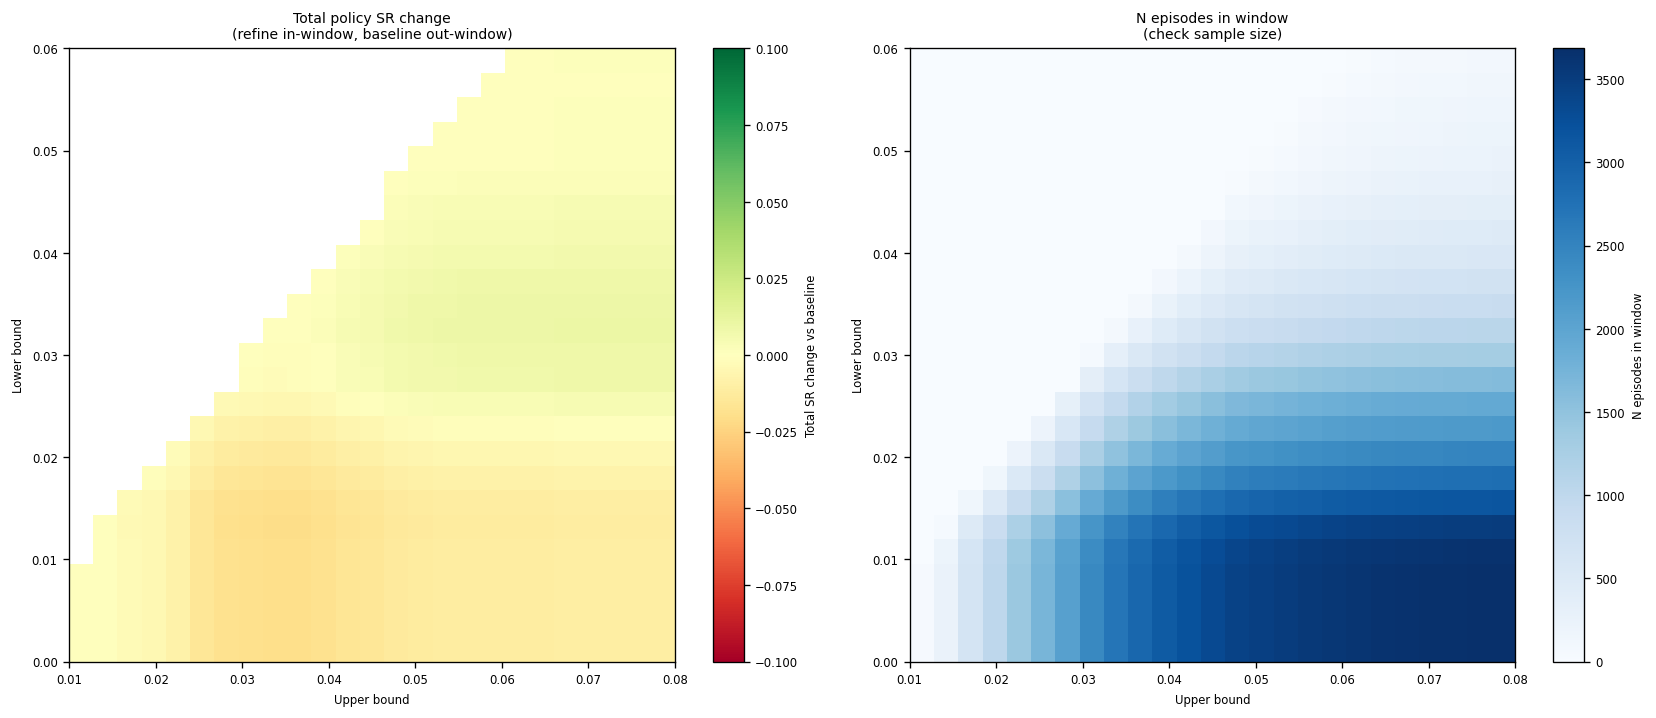


Overall baseline SR (all 3700 paired eps): 0.301
All SR figures are WHOLE-DATASET: baseline vs. the selective policy
(refine episodes with U in [Lower,Upper], keep baseline for the rest).
N_ref = number of episodes refined in that window.

TOP 10 windows by whole-dataset SR change:
   Lower    Upper  N_ref   BaseSR  PolicySR  SRchange
----------------------------------------------------
   0.033    0.068   1025    0.301     0.310    +0.009
   0.033    0.071   1038    0.301     0.310    +0.009
   0.033    0.074   1048    0.301     0.310    +0.009
   0.033    0.077   1058    0.301     0.310    +0.009
   0.033    0.080   1063    0.301     0.310    +0.009
   0.035    0.068    830    0.301     0.310    +0.009
   0.035    0.071    843    0.301     0.310    +0.009
   0.035    0.074    853    0.301     0.310    +0.009
   0.035    0.077    863    0.301     0.310    +0.009
   0.035    0.080    868    0.301     0.310    +0.009

BOTTOM 10 windows by whole-dataset SR change (most degradation):
   

In [15]:
# ── A4. Threshold Window Sweep (fixed for the averaged DB) ─────────────────────
# Changes vs. original A4, both required for this DB:
#   (1) read the SAME DB as A1 (was hard-coded to the old rollouts_jeff_2_0.db)
#   (2) build the baseline from the uncertainty (no-op) pass, since this DB has
#       no pnp_enabled==0 rows. Under the verified no-op, unc_success == vanilla.
import sqlite3, numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42

# (1) use A1's DB if defined, else fall back to the averaged DB explicitly
DB_PATH_JEFF = globals().get(
    'DB_PATH',
    '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_enlarged_merged.db')
con = sqlite3.connect(DB_PATH_JEFF)
df  = pd.read_sql('SELECT * FROM rollouts', con)
con.close()

keys = ['suite','task_idx','episode_idx','init_state_hash']

# (2) baseline := uncertainty pass (no-op ⇒ same trajectory as vanilla).
#     If a real pnp_enabled==0 baseline exists, prefer it; otherwise use uncertainty.
base_src = df[df.pnp_enabled == 0]
if len(base_src) == 0:
    base_src = df[(df.pnp_enabled == 1) & (df.pnp_mode == 'uncertainty')]
    print(f'No pnp_enabled==0 rows; using uncertainty pass as baseline '
          f'({len(base_src)} rows).')
base = base_src[keys + ['success']].rename(columns={'success':'base_success'})
unc  = df[(df.pnp_enabled==1)&(df.pnp_mode=='uncertainty')]\
         [keys + ['success','u_mean_episode']].rename(columns={'success':'unc_success'})
ref  = df[(df.pnp_enabled==1)&(df.pnp_mode=='both')]\
         [keys + ['success']].rename(columns={'success':'ref_success'})

# dedup guard so the inner merges can't many-to-many inflate
for nm, d in [('base',base),('unc',unc),('ref',ref)]:
    dup = d.duplicated(subset=keys).sum()
    if dup: print(f'  ⚠ {nm}: {dup} duplicate keys (keeping first).')
base = base.drop_duplicates(keys); unc = unc.drop_duplicates(keys); ref = ref.drop_duplicates(keys)

paired = base.merge(unc, on=keys, how='inner').merge(ref, on=keys, how='inner')

total_n         = len(paired)
overall_base_sr = paired.base_success.mean()
print(f'Total paired episodes: {total_n}')
print(f'Overall baseline SR:   {overall_base_sr:.3f}')
if total_n == 0:
    raise SystemExit('Pairing empty — check that all three passes share init_state_hash/seeds.')

# ── Sweep ─────────────────────────────────────────────────────────────────────
lower_bounds = np.linspace(0.0,  0.06, 25)
upper_bounds = np.linspace(0.01, 0.08, 25)
sr_change_total = np.full((len(lower_bounds), len(upper_bounds)), np.nan)
n_episodes      = np.zeros((len(lower_bounds), len(upper_bounds)))

for i, lo in enumerate(lower_bounds):
    for j, hi in enumerate(upper_bounds):
        if hi <= lo: continue
        in_window  = paired[(paired.u_mean_episode >= lo) & (paired.u_mean_episode <= hi)]
        out_window = paired[(paired.u_mean_episode <  lo) | (paired.u_mean_episode >  hi)]
        if len(in_window) < 10: continue
        n_episodes[i, j] = len(in_window)
        successes_in  = in_window.ref_success.sum()
        successes_out = out_window.base_success.sum()
        sr_change_total[i, j] = (successes_in + successes_out) / total_n - overall_base_sr

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im1 = axes[0].imshow(sr_change_total, aspect='auto', origin='lower', cmap='RdYlGn',
                     vmin=-0.1, vmax=0.1,
                     extent=[upper_bounds[0], upper_bounds[-1], lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im1, ax=axes[0], label='Total SR change vs baseline')
axes[0].set_xlabel('Upper bound'); axes[0].set_ylabel('Lower bound')
axes[0].set_title('Total policy SR change\n(refine in-window, baseline out-window)')
im2 = axes[1].imshow(n_episodes, aspect='auto', origin='lower', cmap='Blues',
                     extent=[upper_bounds[0], upper_bounds[-1], lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im2, ax=axes[1], label='N episodes in window')
axes[1].set_xlabel('Upper bound'); axes[1].set_ylabel('Lower bound')
axes[1].set_title('N episodes in window\n(check sample size)')
plt.tight_layout()
plt.savefig(DB_PATH_JEFF.rsplit('/',1)[0] + '/threshold_2d_heatmap_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top/bottom windows ────────────────────────────────────────────────────────
results = []
for i, lo in enumerate(lower_bounds):
    for j, hi in enumerate(upper_bounds):
        if np.isnan(sr_change_total[i, j]) or n_episodes[i, j] < 20: continue
        in_window  = paired[(paired.u_mean_episode >= lo) & (paired.u_mean_episode <= hi)]
        out_window = paired[(paired.u_mean_episode <  lo) | (paired.u_mean_episode >  hi)]
        successes_in  = in_window.ref_success.sum(); successes_out = out_window.base_success.sum()
        total_sr_policy = (successes_in + successes_out) / total_n
        results.append({'lo':lo,'hi':hi,'n':len(in_window),
            'total_sr_change':total_sr_policy-overall_base_sr,
            'base_sr_window':in_window.base_success.mean(),
            'ref_sr_window':in_window.ref_success.mean(),'total_sr_policy':total_sr_policy})
results_df = pd.DataFrame(results)
hdr = (f'{"Lower":>8} {"Upper":>8} {"N_ref":>6} '
       f'{"BaseSR":>8} {"PolicySR":>9} {"SRchange":>9}')
sep = '-'*52
print(f'\nOverall baseline SR (all {total_n} paired eps): {overall_base_sr:.3f}')
print('All SR figures are WHOLE-DATASET: baseline vs. the selective policy\n'
      '(refine episodes with U in [Lower,Upper], keep baseline for the rest).\n'
      'N_ref = number of episodes refined in that window.')
if len(results_df):
    print(f'\n{"==="*20}\nTOP 10 windows by whole-dataset SR change:')
    print(hdr); print(sep)
    for _, r in results_df.nlargest(10,'total_sr_change').iterrows():
        print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
              f'{overall_base_sr:>8.3f} {r.total_sr_policy:>9.3f} {r.total_sr_change:>+9.3f}')
    print(f'\n{"==="*20}\nBOTTOM 10 windows by whole-dataset SR change (most degradation):')
    print(hdr); print(sep)
    for _, r in results_df.nsmallest(10,'total_sr_change').iterrows():
        print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
              f'{overall_base_sr:>8.3f} {r.total_sr_policy:>9.3f} {r.total_sr_change:>+9.3f}')
else:
    print('No windows met the N>=20 threshold.')

Window U ∈ [0.033, 0.080]  |  3700 paired episodes, 1023 refined (28%)
Whole-dataset baseline SR: 30.05%
Whole-dataset policy   SR: 31.22%   (Δ +1.16 pp)



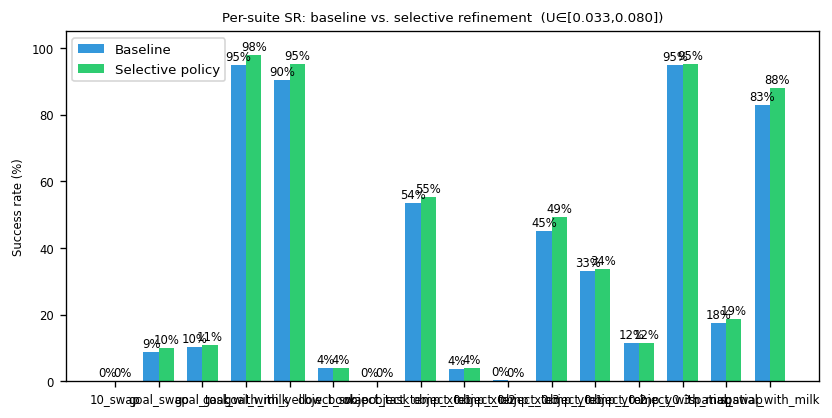

Per-suite SR change (baseline → selective policy):
  libero_10_swap                             0.0% →   0.0%  ( +0.0 pp, 133 refined)
  libero_goal_swap                           8.8% →  10.0%  ( +1.2 pp, 192 refined)
  libero_goal_task                          10.4% →  10.8%  ( +0.4 pp, 62 refined)
  libero_goal_with_milk                     95.0% →  98.0%  ( +3.0 pp, 10 refined)
  libero_goal_with_yellow_book              90.4% →  95.2%  ( +4.8 pp, 37 refined)
  libero_object_swap                         4.0% →   4.0%  ( +0.0 pp, 42 refined)
  libero_object_task                         0.0% →   0.0%  ( +0.0 pp, 5 refined)
  libero_object_temp_x0.1                   53.6% →  55.2%  ( +1.6 pp, 21 refined)
  libero_object_temp_x0.2                    3.6% →   4.0%  ( +0.4 pp, 71 refined)
  libero_object_temp_x0.3                    0.4% →   0.0%  ( -0.4 pp, 79 refined)
  libero_object_temp_y0.1                   45.2% →  49.2%  ( +4.0 pp, 35 refined)
  libero_object_temp_y0.2          

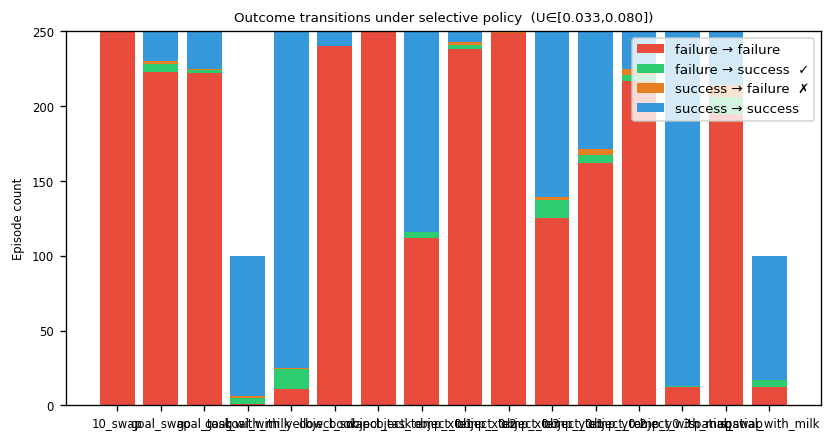


Per-suite transitions (F→S recoveries vs S→F disruptions):
  libero_10_swap                           F→S=  0  S→F=  0  net=+0
  libero_goal_swap                         F→S=  5  S→F=  2  net=+3
  libero_goal_task                         F→S=  2  S→F=  1  net=+1
  libero_goal_with_milk                    F→S=  4  S→F=  1  net=+3
  libero_goal_with_yellow_book             F→S= 13  S→F=  1  net=+12
  libero_object_swap                       F→S=  0  S→F=  0  net=+0
  libero_object_task                       F→S=  0  S→F=  0  net=+0
  libero_object_temp_x0.1                  F→S=  4  S→F=  0  net=+4
  libero_object_temp_x0.2                  F→S=  3  S→F=  2  net=+1
  libero_object_temp_x0.3                  F→S=  0  S→F=  1  net=-1
  libero_object_temp_y0.1                  F→S= 12  S→F=  2  net=+10
  libero_object_temp_y0.2                  F→S=  5  S→F=  4  net=+1
  libero_object_temp_y0.3                  F→S=  4  S→F=  4  net=+0
  libero_object_with_mug                   F→S=  1  S→

In [16]:
# ── A2/A3 under a CUSTOM uncertainty threshold window ──────────────────────────
# Set the window here. An episode takes the REFINED outcome iff its per-episode
# uncertainty U falls in [LOWER, UPPER]; otherwise it keeps the BASELINE outcome
# (same selective policy A4 sweeps). Reproduces A2 (per-suite SR + aggregate change)
# and A3 (episode transitions) for that single chosen window.
#
# Run after A1 (needs `phase2`, `phase3`, pd, np, plt). Baseline = uncertainty
# (no-op) pass, consistent with the A3/A4 fixes.
LOWER = 0.033      # ← edit
UPPER = 0.08      # ← edit

import numpy as np, pandas as pd, matplotlib.pyplot as plt

keys = ['suite','task_idx','episode_idx','init_state_hash']

# Baseline := no-op (uncertainty) pass. Prefer a real pnp_enabled==0 set if present.
_base_src = baseline if ('baseline' in globals() and len(baseline)) else phase2
base = _base_src[keys + ['success']].rename(columns={'success':'base_success'})
unc  = phase2[keys + ['success','u_mean_episode']].rename(columns={'success':'unc_success'})
ref  = phase3[keys + ['success']].rename(columns={'success':'ref_success'})
for nm,d in [('base',base),('unc',unc),('ref',ref)]:
    dup=d.duplicated(subset=keys).sum()
    if dup: print(f'  ⚠ {nm}: {dup} dup keys (keeping first).')
base=base.drop_duplicates(keys); unc=unc.drop_duplicates(keys); ref=ref.drop_duplicates(keys)

paired = base.merge(unc, on=keys, how='inner').merge(ref, on=keys, how='inner')
if len(paired)==0:
    raise SystemExit('Empty pairing — passes do not share init_state_hash/seeds.')

# Selective policy outcome for this window
in_win = paired.u_mean_episode.between(LOWER, UPPER)
paired['in_window']      = in_win
paired['policy_success'] = np.where(in_win, paired.ref_success, paired.base_success)

n_ref  = int(in_win.sum())
b_sr   = paired.base_success.mean()
p_sr   = paired.policy_success.mean()
print(f'Window U ∈ [{LOWER:.3f}, {UPPER:.3f}]  |  {len(paired)} paired episodes, '
      f'{n_ref} refined ({n_ref/len(paired):.0%})')
print(f'Whole-dataset baseline SR: {b_sr*100:.2f}%')
print(f'Whole-dataset policy   SR: {p_sr*100:.2f}%   (Δ {(p_sr-b_sr)*100:+.2f} pp)\n')

# ── A2-style: per-suite baseline vs. selective-policy SR ──────────────────────
suites = sorted(paired.suite.unique())
sr_base = paired.groupby('suite').base_success.mean().reindex(suites).fillna(0)
sr_pol  = paired.groupby('suite').policy_success.mean().reindex(suites).fillna(0)

x=np.arange(len(suites)); w=0.35
fig,ax=plt.subplots(figsize=(7,3.5))
bb=ax.bar(x-w/2, sr_base*100, width=w, label='Baseline',        color='#3498db')
bp=ax.bar(x+w/2, sr_pol*100,  width=w, label='Selective policy', color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=0, ha='center')
ax.set_ylabel('Success rate (%)'); ax.set_ylim(0,105)
ax.set_title(f'Per-suite SR: baseline vs. selective refinement  (U∈[{LOWER:.3f},{UPPER:.3f}])', fontsize=8)
ax.legend(fontsize=8)
for bars,vals in [(bb,sr_base),(bp,sr_pol)]:
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v*100:.0f}%',
                ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()

print('Per-suite SR change (baseline → selective policy):')
for s in suites:
    d=(sr_pol[s]-sr_base[s])*100
    nref=int(paired[(paired.suite==s)].in_window.sum())
    print(f'  {s:<40} {sr_base[s]*100:5.1f}% → {sr_pol[s]*100:5.1f}%  ({d:+5.1f} pp, {nref} refined)')

# ── A3-style: episode transitions (only the refined episodes can transition) ──
def _trans(r):
    b,p=int(r.base_success),int(r.policy_success)
    if b==1 and p==1: return 'success → success'
    if b==0 and p==1: return 'failure → success  ✓'
    if b==1 and p==0: return 'success → failure  ✗'
    return 'failure → failure'
paired['transition']=paired.apply(_trans, axis=1)

print('\nOverall transition counts (whole dataset under the policy):')
print(paired['transition'].value_counts().to_string())
# transitions are driven entirely by refined episodes; show that subset too
ref_only=paired[paired.in_window]
print(f'\nAmong the {n_ref} refined episodes only:')
print(ref_only['transition'].value_counts().to_string())

cats=['failure → failure','failure → success  ✓','success → failure  ✗','success → success']
cat_colors=['#e74c3c','#2ecc71','#e67e22','#3498db']
fig,ax=plt.subplots(figsize=(7,3.7)); bottom=np.zeros(len(suites))
for cat,color in zip(cats,cat_colors):
    vals=[paired[paired.suite==s]['transition'].value_counts().get(cat,0) for s in suites]
    ax.bar(range(len(suites)), vals, bottom=bottom, label=cat, color=color)
    bottom+=np.array(vals,dtype=float)
ax.set_xticks(range(len(suites))); ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=0, ha='center')
ax.set_ylabel('Episode count')
ax.set_title(f'Outcome transitions under selective policy  (U∈[{LOWER:.3f},{UPPER:.3f}])', fontsize=8)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

print('\nPer-suite transitions (F→S recoveries vs S→F disruptions):')
for s in suites:
    tc=paired[paired.suite==s]['transition'].value_counts()
    f2s=tc.get('failure → success  ✓',0); s2f=tc.get('success → failure  ✗',0)
    print(f'  {s:<40} F→S={f2s:>3}  S→F={s2f:>3}  net={f2s-s2f:+d}')

## A5. ROC / AUC — Uncertainty as Failure Predictor

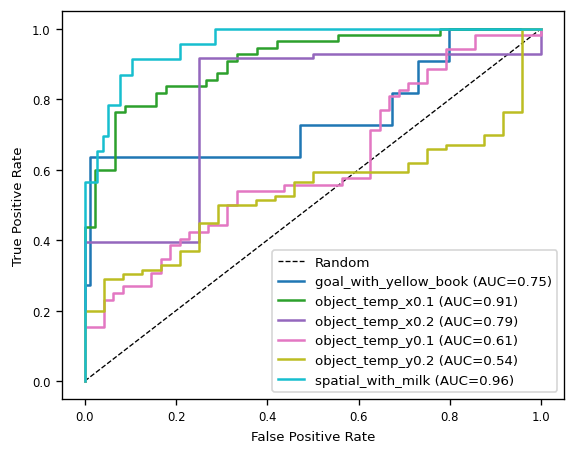


AUC by suite:
  libero_spatial_with_milk                      AUC=0.959  [distractor]
  libero_object_temp_x0.1                       AUC=0.909  [pos_perturb]
  libero_object_temp_x0.2                       AUC=0.792  [pos_perturb]
  libero_goal_with_yellow_book                  AUC=0.753  [distractor]
  libero_object_temp_y0.1                       AUC=0.611  [pos_perturb]
  libero_object_temp_y0.2                       AUC=0.537  [pos_perturb]

Mean AUC across suites: 0.760


In [ ]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42

matplotlib.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype':  42,
    'font.size':    80,        # base font size
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
})

if len(phase2) == 0:
    print('No Phase 2 data yet.')
else:
    sub = phase2.dropna(subset=['u_mean_episode'])
    suites = sorted(sub['suite'].unique())

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0,1],[0,1],'k--',lw=0.8, label='Random')

    auc_results = {}
    colors_suite = plt.cm.tab10(np.linspace(0, 1, len(suites)))

    for suite, color in zip(suites, colors_suite):
        g = sub[sub.suite == suite]
        if g['success'].nunique() < 2:
            print(f'  Skipping {suite}: only one outcome class present')
            continue
        # Higher uncertainty → predicts failure (success=0)
        fpr, tpr, _ = roc_curve(1 - g['success'], g['u_mean_episode'])
        roc_auc = auc(fpr, tpr)
        auc_results[suite] = roc_auc
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f'{suite.replace("libero_","")} (AUC={roc_auc:.2f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    # ax.set_title('ROC: uncertainty as failure predictor (Phase 2)')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/roc_curves.png', dpi=150)
    plt.show()

    print('\nAUC by suite:')
    for suite, a_val in sorted(auc_results.items(), key=lambda x: -x[1]):
        stype = 'pos_perturb' if 'temp_' in suite else 'distractor'
        print(f'  {suite:<45} AUC={a_val:.3f}  [{stype}]')

    if auc_results:
        overall_auc = np.mean(list(auc_results.values()))
        print(f'\nMean AUC across suites: {overall_auc:.3f}')

## B: Geometric Analysis

In [ ]:
DB_PATH = f'{RESULTS_DIR}/rollouts_jeff_2_multimodal.db'
import sqlite3
con = sqlite3.connect(DB_PATH)   # reopen — a prior cell had closed it

real_before  = con.execute("SELECT COUNT(*) FROM rollouts WHERE rollout_id NOT LIKE 'synthbase_%'").fetchone()[0]
synth_before = con.execute("SELECT COUNT(*) FROM rollouts WHERE rollout_id LIKE 'synthbase_%'").fetchone()[0]
print(f'before: {real_before} real rollouts, {synth_before} synthetic')

con.execute("DELETE FROM rollouts WHERE rollout_id LIKE 'synthbase_%'")   # only ever removes prior synthbase rows
con.execute("""
INSERT INTO rollouts (rollout_id, suite, task_idx, episode_idx, init_state_hash,
    success, n_steps, elapsed_s, pnp_enabled, timestamp)
SELECT 'synthbase_'||rollout_id, suite, task_idx, episode_idx, init_state_hash,
    success, n_steps, elapsed_s, 0, timestamp
FROM rollouts WHERE pnp_enabled=1 AND pnp_mode='uncertainty'
""")
con.commit()

real_after  = con.execute("SELECT COUNT(*) FROM rollouts WHERE rollout_id NOT LIKE 'synthbase_%'").fetchone()[0]
synth_after = con.execute("SELECT COUNT(*) FROM rollouts WHERE rollout_id LIKE 'synthbase_%'").fetchone()[0]
print(f'after : {real_after} real rollouts, {synth_after} synthetic')
assert real_after == real_before, 'real rollouts changed — STOP and investigate'
print('Real results untouched ✓')

before: 1200 real rollouts, 600 synthetic
after : 1200 real rollouts, 600 synthetic
Real results untouched ✓


In [ ]:
import sqlite3, json, numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

c = sqlite3.connect(DB_PATH)
roll  = pd.read_sql("SELECT * FROM rollouts WHERE pnp_enabled=1 AND pnp_mode='uncertainty'", c)
steps = pd.read_sql("SELECT rollout_id, chunk_idx, u_mean FROM pnp_euler_steps", c)
vec   = pd.read_sql("SELECT rollout_id, a_std_vec FROM pnp_action_vectors", c)
try:
    msb = pd.read_sql("SELECT init_state_hash, ms_pair_l2 FROM baseline_uncertainty", c)
except Exception:
    msb = pd.DataFrame(columns=['init_state_hash','ms_pair_l2'])
c.close()

u0 = (steps[steps.chunk_idx == 0].groupby('rollout_id')['u_mean'].mean()
      .reset_index().rename(columns={'u_mean':'u_first_chunk'}))
def _astd(s):
    vals = [np.mean(json.loads(x)) for x in s if x and x != '[]']
    return float(np.mean(vals)) if vals else np.nan
astd = (vec.groupby('rollout_id')['a_std_vec'].apply(_astd)
        .reset_index().rename(columns={'a_std_vec':'a_std'}))

df = roll.merge(u0, on='rollout_id', how='left').merge(astd, on='rollout_id', how='left')
if not msb.empty:
    ms = (msb.groupby('init_state_hash')['ms_pair_l2'].mean()
          .reset_index().rename(columns={'ms_pair_l2':'ms'}))
    df = df.merge(ms, on='init_state_hash', how='left')
else:
    df['ms'] = np.nan

MEASURES = [('u_mean_episode','P&P u_mean (episode)'), ('u_first_chunk','P&P u (chunk 0)'),
            ('a_std','P&P a_std (free)'), ('mm_bc_pc1_episode','PC1 bimodality'),
            ('ms','multi-sample var (chunk 0)')]
suites = sorted(df['suite'].dropna().unique())
rows = []
for col, label in MEASURES:
    if col not in df.columns: continue
    per = {}
    for su in suites:
        s = df[df.suite == su].dropna(subset=[col, 'success'])
        if s['success'].nunique() < 2 or len(s) < 10: per[su] = np.nan; continue
        try: per[su] = roc_auc_score(1 - s['success'], s[col])
        except Exception: per[su] = np.nan
    rows.append({'measure': label,
                 **{su.replace('libero_','').replace('object_',''):
                    (round(per[su],3) if per[su]==per[su] else np.nan) for su in suites},
                 'mean': round(np.nanmean(list(per.values())),3)})
print(pd.DataFrame(rows).to_string(index=False))
print('\nWithin-suite AUC (failure prediction). Compare ms vs P&P u (chunk 0): same probe point.')
print('Per-suite columns + their mean are the honest numbers — never pool episodes across suites.')


                   measure  goal_with_yellow_book  temp_x0.1  temp_x0.2  temp_y0.1  temp_y0.2  spatial_with_milk  mean
      P&P u_mean (episode)                  0.772      0.919      0.820      0.621      0.530              0.949 0.769
           P&P u (chunk 0)                  0.442      0.542      0.440      0.534      0.492              0.717 0.528
          P&P a_std (free)                  0.776      0.914      0.812      0.622      0.525              0.960 0.768
            PC1 bimodality                  0.613      0.522      0.484      0.397      0.493              0.533 0.507
multi-sample var (chunk 0)                    NaN        NaN        NaN        NaN        NaN                NaN   NaN

Within-suite AUC (failure prediction). Compare ms vs P&P u (chunk 0): same probe point.
Per-suite columns + their mean are the honest numbers — never pool episodes across suites.


/tmp/ipykernel_694/815219915.py:46: RuntimeWarning: Mean of empty slice
  'mean': round(np.nanmean(list(per.values())),3)})


## Multimodality decomposition — does bimodality explain high-U successes?

Among high-U episodes, test whether PC1 bimodality predicts *success* (multimodal = several valid plans) vs failure (diffuse/unstable). If `BC|succ > BC|fail` and AUC > ~0.6, multimodality explains the high-U-success false positives that cap F1.

In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

d = df.dropna(subset=['u_mean_episode','mm_bc_pc1_episode','success']).copy()
print(f'{"suite":<26}{"n_highU":>8}{"n_S":>6}{"n_F":>6}{"BC|succ":>9}{"BC|fail":>9}{"AUC(BC->succ)":>15}')
print('-'*79)
aucs = []
for su in sorted(d['suite'].unique()):
    s = d[d.suite == su]; thr = s['u_mean_episode'].median()
    hi = s[s['u_mean_episode'] >= thr]
    if hi['success'].nunique() < 2 or len(hi) < 8:
        print(f'{su.replace("libero_","")[:26]:<26}{len(hi):>8}{"–":>6}{"–":>6}{"–":>9}{"–":>9}{"(too few)":>15}')
        continue
    bc_s = hi[hi.success==1]['mm_bc_pc1_episode'].mean()
    bc_f = hi[hi.success==0]['mm_bc_pc1_episode'].mean()
    n_s  = int((hi.success==1).sum())
    n_f  = int((hi.success==0).sum())
    auc  = roc_auc_score(hi['success'], hi['mm_bc_pc1_episode'])
    aucs.append(auc)
    print(f'{su.replace("libero_","")[:26]:<26}{len(hi):>8}{n_s:>6}{n_f:>6}'
          f'{bc_s:>9.3f}{bc_f:>9.3f}{auc:>15.3f}')
print('-'*79)
print(f'mean within-suite AUC(bimodality -> success | high-U): {np.nanmean(aucs):.3f}'
      if aucs else 'no suites with enough high-U episodes')
print('If BC|succ > BC|fail and AUC > ~0.6, multimodality explains the high-U successes.')

suite                      n_highU   n_S   n_F  BC|succ  BC|fail  AUC(BC->succ)
-------------------------------------------------------------------------------
goal_with_yellow_book           50    42     8    0.391    0.407          0.318
object_temp_x0.1                50     6    44    0.403    0.409          0.492
object_temp_x0.2                50     1    49    0.368    0.414          0.000
object_temp_y0.1                50    21    29    0.427    0.407          0.609
object_temp_y0.2                50    11    39    0.411    0.412          0.487
spatial_with_milk               50    27    23    0.394    0.404          0.424
-------------------------------------------------------------------------------
mean within-suite AUC(bimodality -> success | high-U): 0.388
If BC|succ > BC|fail and AUC > ~0.6, multimodality explains the high-U successes.


    dim  mean_auc  n_suites
      x  0.703175         6
      y  0.742390         6
      z  0.764321         6
   roll  0.695542         6
  pitch  0.712770         6
    yaw  0.725177         6
gripper  0.704952         6

all-dims (mean U) baseline AUC: 0.760
If every per-dim AUC ~= the all-dims baseline, no single dimension localizes the signal.


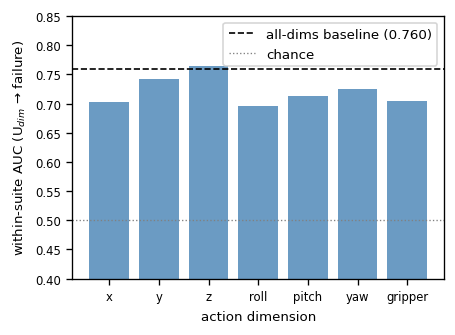

In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3
matplotlib.rcParams['ps.fonttype'] = 42

# ── Per-dimension uncertainty AUC: does any single action dim carry the failure signal? ──
import sqlite3, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DB_PATH = f'{RESULTS_DIR}/rollouts_jeff_2_averages.db'   # set to the verified-no-op DB
DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']

c = sqlite3.connect(DB_PATH)
roll = pd.read_sql(
    "SELECT rollout_id, suite, success FROM rollouts "
    "WHERE pnp_enabled=1 AND pnp_mode='uncertainty'", c)
av = pd.read_sql(
    "SELECT rollout_id, u_vec FROM pnp_action_vectors", c)
c.close()

# parse the 7-d u_vec JSON, average over all (chunk, euler_step) rows per rollout
av = av.dropna(subset=['u_vec']).copy()
av['u_arr'] = av['u_vec'].apply(lambda s: np.asarray(json.loads(s), dtype=float))
av = av[av['u_arr'].apply(lambda a: a.shape == (7,))]
per_roll = (av.groupby('rollout_id')['u_arr']
            .apply(lambda g: np.mean(np.stack(g.values), axis=0)))
per_roll = per_roll.reset_index()
per_roll[DIM_NAMES] = pd.DataFrame(per_roll['u_arr'].tolist(), index=per_roll.index)

d = roll.merge(per_roll.drop(columns='u_arr'), on='rollout_id', how='inner')
d['fail'] = 1 - d['success']
suites = sorted(d['suite'].unique())

# within-suite AUC of each per-dim U -> failure, averaged across suites
rows = []
for dim in DIM_NAMES:
    per_suite = []
    for su in suites:
        s = d[d.suite == su].dropna(subset=[dim, 'fail'])
        if s['fail'].nunique() == 2 and len(s) >= 10:
            per_suite.append(roc_auc_score(s['fail'], s[dim]))
    rows.append({'dim': dim, 'mean_auc': np.nanmean(per_suite),
                 'n_suites': len(per_suite)})
res = pd.DataFrame(rows)

# also the all-dims (episode u_mean) baseline for reference
all_dim_auc = []
d['u_all'] = d[DIM_NAMES].mean(axis=1)
for su in suites:
    s = d[d.suite == su].dropna(subset=['u_all', 'fail'])
    if s['fail'].nunique() == 2 and len(s) >= 10:
        all_dim_auc.append(roc_auc_score(s['fail'], s['u_all']))
all_dim_auc = np.nanmean(all_dim_auc)

print(res.to_string(index=False))
print(f'\nall-dims (mean U) baseline AUC: {all_dim_auc:.3f}')
print('If every per-dim AUC ~= the all-dims baseline, no single dimension localizes the signal.')

# ── plot ──
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(res['dim'], res['mean_auc'], color='steelblue', alpha=0.8)
ax.axhline(all_dim_auc, color='black', linestyle='--', linewidth=1,
           label=f'all-dims baseline ({all_dim_auc:.3f})')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label='chance')
ax.set_ylabel('within-suite AUC (U$_{dim}$ → failure)')
ax.set_xlabel('action dimension')
ax.set_ylim(0.4, max(0.85, res['mean_auc'].max() + 0.05))
# ax.set_title('Per-dimension uncertainty as failure predictor')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('per_dim_auc.pdf', bbox_inches='tight')
plt.show()

# Thresholded Version of Dimension-Localization Test

U band [0.028, +inf]: 820/2200 episodes retained (overall fail rate 80.7% vs 54.5% unrestricted)
    dim  auc_band  n_suites  auc_unrestricted
      x     0.690        10             0.712
      y     0.536        10             0.652
      z     0.629        10             0.702
   roll     0.557        10             0.649
  pitch     0.594        10             0.669
    yaw     0.608        10             0.724
gripper     0.653        10             0.660

all-dims (mean U) AUC — band: 0.692   unrestricted: 0.714
Per-dim AUC spread within band (max-min): 0.154  → small spread = still not subspace-localized, even in the uncertain band.
(Absolute AUCs are expected to sit lower than unrestricted due to range restriction; read the FLATNESS across dims, not the level.)


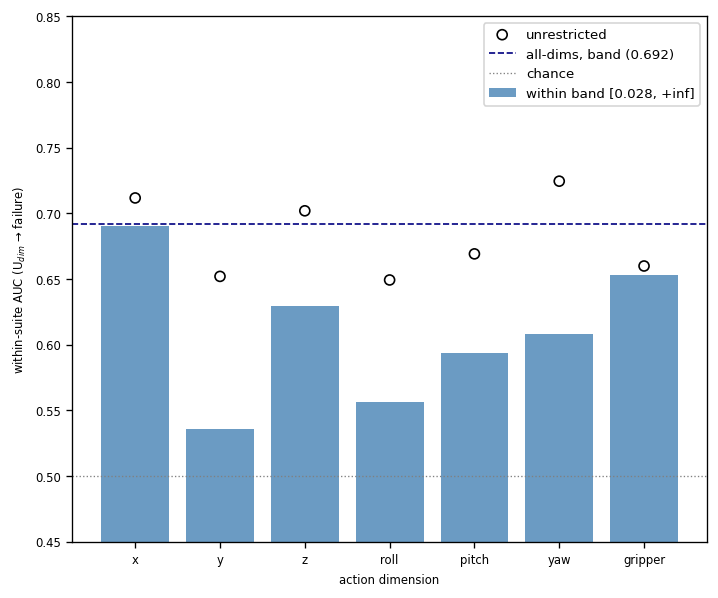

In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3
matplotlib.rcParams['ps.fonttype'] = 42

# ── Per-dimension uncertainty AUC, with optional thresholding on overall U ─────
# Set either bound to None to leave it open. The window is applied to each
# episode's mean uncertainty u_all; AUC is then computed WITHIN that band.
#
# NOTE ON INTERPRETATION: u_dim is a component of the u_all you filter on, so
# restricting the band restricts the range of the predictor and will generally
# pull every per-dim AUC toward 0.5 (range-restriction attenuation). The useful
# question is therefore whether the per-dim AUCs stay FLAT relative to one another
# (and to the all-dims baseline) within the band — not their absolute level. The
# unrestricted AUC is printed alongside for reference.
U_LOWER = 0.028      # e.g. 0.028, or None
U_UPPER = None      # e.g. 0.068, or None
MIN_PER_SUITE = 10  # min episodes (with both classes) to score a suite

import sqlite3, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DB_PATH = f'{RESULTS_DIR}/rollouts_enlarged_ppd.db'   # verified-no-op DB
DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']

c = sqlite3.connect(DB_PATH)
roll = pd.read_sql(
    "SELECT rollout_id, suite, success FROM rollouts "
    "WHERE pnp_enabled=1 AND pnp_mode='uncertainty'", c)
av = pd.read_sql("SELECT rollout_id, u_vec FROM pnp_action_vectors", c)
c.close()

# parse the 7-d u_vec JSON, average over all (chunk, euler_step) rows per rollout
av = av.dropna(subset=['u_vec']).copy()
av['u_arr'] = av['u_vec'].apply(lambda s: np.asarray(json.loads(s), dtype=float))
av = av[av['u_arr'].apply(lambda a: a.shape == (7,))]
per_roll = (av.groupby('rollout_id')['u_arr']
            .apply(lambda g: np.mean(np.stack(g.values), axis=0)).reset_index())
per_roll[DIM_NAMES] = pd.DataFrame(per_roll['u_arr'].tolist(), index=per_roll.index)

d = roll.merge(per_roll.drop(columns='u_arr'), on='rollout_id', how='inner')
d['fail']  = 1 - d['success']
d['u_all'] = d[DIM_NAMES].mean(axis=1)

# ── apply the optional threshold window on overall uncertainty ────────────────
n_before = len(d)
mask = pd.Series(True, index=d.index)
if U_LOWER is not None: mask &= d['u_all'] >= U_LOWER
if U_UPPER is not None: mask &= d['u_all'] <= U_UPPER
d_band = d[mask].copy()
band_str = f'[{U_LOWER if U_LOWER is not None else "-inf"}, {U_UPPER if U_UPPER is not None else "+inf"}]'
print(f'U band {band_str}: {len(d_band)}/{n_before} episodes retained '
      f'(overall fail rate {d_band.fail.mean():.1%} vs {d.fail.mean():.1%} unrestricted)')

def within_suite_auc(frame, col):
    per_suite = []
    for su in sorted(frame['suite'].unique()):
        s = frame[frame.suite == su].dropna(subset=[col, 'fail'])
        if s['fail'].nunique() == 2 and len(s) >= MIN_PER_SUITE:
            per_suite.append(roc_auc_score(s['fail'], s[col]))
    return (np.nanmean(per_suite) if per_suite else np.nan), len(per_suite)

# per-dim AUC in the band, plus the unrestricted value for reference
rows = []
for dim in DIM_NAMES:
    auc_band, n_b = within_suite_auc(d_band, dim)
    auc_full, _   = within_suite_auc(d,      dim)
    rows.append({'dim': dim, 'auc_band': auc_band, 'n_suites': n_b, 'auc_unrestricted': auc_full})
res = pd.DataFrame(rows)

all_band, _ = within_suite_auc(d_band, 'u_all')
all_full, _ = within_suite_auc(d,      'u_all')

pd.set_option('display.float_format', lambda x: f'{x:.3f}')
print(res.to_string(index=False))
print(f'\nall-dims (mean U) AUC — band: {all_band:.3f}   unrestricted: {all_full:.3f}')
spread = np.nanmax(res.auc_band) - np.nanmin(res.auc_band)
print(f'Per-dim AUC spread within band (max-min): {spread:.3f}  '
      f'→ small spread = still not subspace-localized, even in the uncertain band.')
if U_LOWER is not None or U_UPPER is not None:
    print('(Absolute AUCs are expected to sit lower than unrestricted due to range '
          'restriction; read the FLATNESS across dims, not the level.)')

# ── plot: band AUC bars, with unrestricted as hollow markers for contrast ─────
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(res['dim'], res['auc_band'], color='steelblue', alpha=0.8,
       label=f'within band {band_str}')
ax.scatter(res['dim'], res['auc_unrestricted'], facecolors='none', edgecolors='black',
           zorder=3, label='unrestricted')
ax.axhline(all_band, color='navy', linestyle='--', linewidth=1,
           label=f'all-dims, band ({all_band:.3f})')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label='chance')
ax.set_ylabel('within-suite AUC (U$_{dim}$ → failure)')
ax.set_xlabel('action dimension')
lo = min(0.45, np.nanmin(res.auc_band) - 0.05)
hi = max(0.85, np.nanmax(res.auc_unrestricted) + 0.05)
ax.set_ylim(lo, hi)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('per_dim_auc.pdf', bbox_inches='tight')
plt.show()

Uncertainty metric built from dims ['pitch', 'gripper']  (indices [4, 6])
Paired episodes: 2200   whole-dataset baseline SR: 0.455
u_sel range: [0.0106, 0.0945]  median 0.0264

Overall baseline SR (all 2200 eps): 0.455  [metric dims: pitch+gripper]

TOP 10 windows by whole-dataset SR change:
    Lower     Upper  N_ref   BaseSR  PolicySR  SRchange
------------------------------------------------------
   0.0309    0.0945    825    0.455     0.477    +0.023
   0.0323    0.0945    734    0.455     0.475    +0.021
   0.0296    0.0945    917    0.455     0.475    +0.020
   0.0280    0.0945   1008    0.455     0.475    +0.020
   0.0264    0.0945   1100    0.455     0.473    +0.019
   0.0338    0.0945    642    0.455     0.473    +0.019
   0.0356    0.0945    550    0.455     0.473    +0.019
   0.0377    0.0945    459    0.455     0.473    +0.019
   0.0397    0.0945    367    0.455     0.473    +0.019
   0.0426    0.0945    275    0.455     0.472    +0.017

BOTTOM 10 windows by whole-dataset 

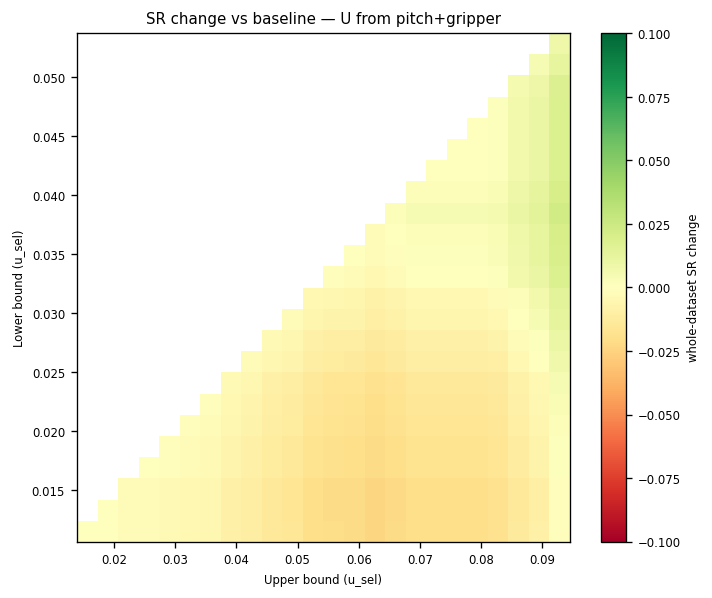

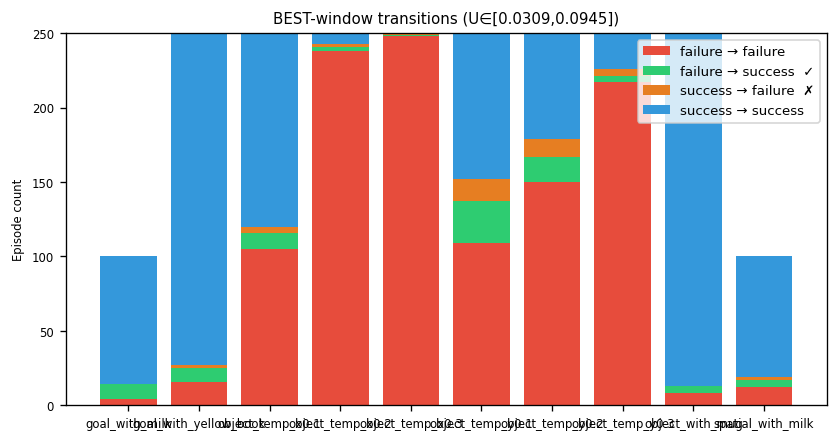

In [ ]:
# ── Window sweep on SELECTED-DIMENSION uncertainty, with A3/A4 diagnostics ─────
# Recomputes per-episode uncertainty from ONLY the chosen action dimensions, sweeps
# [lower, upper] windows (selective policy: refine in-window, baseline out-window),
# reports best/worst windows by WHOLE-DATASET SR change (A4-style), then prints the
# episode-transition breakdown (A3-style) for the single best and worst windows.
#
# Run after A1 (needs RESULTS_DIR, pd, np, plt). Baseline = uncertainty no-op pass.

# ── parameters ────────────────────────────────────────────────────────────────
DIMS        = ['pitch', 'gripper']   # dims used to build the uncertainty metric
GRID_MODE   = 'quantile'   # 'quantile' (data-driven bounds) or 'fixed'
N_GRID      = 25           # grid resolution per axis
FIXED_LOWER = (0.0,  0.06) # (start, stop) used only if GRID_MODE=='fixed'
FIXED_UPPER = (0.01, 0.08)
MIN_IN_WINDOW = 10         # min refined episodes for a window to be scored
MIN_FOR_TABLE = 20         # min refined episodes to appear in top/bottom tables

import sqlite3, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
DB_PATH   = f'{RESULTS_DIR}/rollouts_enlarged_ppd.db'
DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']
keys      = ['suite','task_idx','episode_idx','init_state_hash']

sel_idx = [DIM_NAMES.index(dd) for dd in DIMS]
print(f'Uncertainty metric built from dims {DIMS}  (indices {sel_idx})')

# ── load rollouts (baseline=uncertainty no-op, refinement='both') + per-dim u_vec ─
c = sqlite3.connect(DB_PATH)
roll = pd.read_sql(
    "SELECT rollout_id, suite, task_idx, episode_idx, init_state_hash, success, "
    "pnp_enabled, pnp_mode FROM rollouts", c)
av = pd.read_sql("SELECT rollout_id, u_vec FROM pnp_action_vectors", c)
c.close()

# per-episode selected-dim uncertainty: avg u_vec over all rows, then over chosen dims
av = av.dropna(subset=['u_vec']).copy()
av['u_arr'] = av['u_vec'].apply(lambda s: np.asarray(json.loads(s), dtype=float))
av = av[av['u_arr'].apply(lambda a: a.shape == (len(DIM_NAMES),))]
per_roll = (av.groupby('rollout_id')['u_arr']
            .apply(lambda g: np.mean(np.stack(g.values), axis=0)).reset_index())
per_roll['u_sel'] = per_roll['u_arr'].apply(lambda a: float(np.mean(a[sel_idx])))
u_sel = per_roll[['rollout_id','u_sel']]

# attach u_sel to the uncertainty (no-op) rollouts -> these carry both U and baseline outcome
unc_roll = roll[(roll.pnp_enabled==1)&(roll.pnp_mode=='uncertainty')].merge(u_sel, on='rollout_id', how='inner')

base = unc_roll[keys + ['success']].rename(columns={'success':'base_success'})
unc  = unc_roll[keys + ['success','u_sel']].rename(columns={'success':'unc_success'})
ref  = roll[(roll.pnp_enabled==1)&(roll.pnp_mode=='both')][keys+['success']].rename(columns={'success':'ref_success'})
for nm,df in [('base',base),('unc',unc),('ref',ref)]:
    dup=df.duplicated(subset=keys).sum()
    if dup: print(f'  ⚠ {nm}: {dup} dup keys (keeping first).')
base=base.drop_duplicates(keys); unc=unc.drop_duplicates(keys); ref=ref.drop_duplicates(keys)

paired = base.merge(unc, on=keys, how='inner').merge(ref, on=keys, how='inner')
if len(paired)==0:
    raise SystemExit('Empty pairing — passes do not share init_state_hash/seeds, or no u_vec rows.')
total_n=len(paired); overall_base_sr=paired.base_success.mean()
print(f'Paired episodes: {total_n}   whole-dataset baseline SR: {overall_base_sr:.3f}')
print(f'u_sel range: [{paired.u_sel.min():.4f}, {paired.u_sel.max():.4f}]  '
      f'median {paired.u_sel.median():.4f}')

# ── build the sweep grid on the u_sel scale ───────────────────────────────────
if GRID_MODE=='quantile':
    qs = paired.u_sel.quantile(np.linspace(0.0,1.0,N_GRID)).values
    lower_bounds = np.unique(qs); upper_bounds = np.unique(qs)
else:
    lower_bounds = np.linspace(*FIXED_LOWER, N_GRID)
    upper_bounds = np.linspace(*FIXED_UPPER, N_GRID)

# ── sweep: whole-dataset SR under selective policy ────────────────────────────
recs=[]
for lo in lower_bounds:
    for hi in upper_bounds:
        if hi<=lo: continue
        inw = paired.u_sel.between(lo,hi)
        n_ref=int(inw.sum())
        if n_ref < MIN_IN_WINDOW: continue
        succ_in  = paired.loc[inw,'ref_success'].sum()
        succ_out = paired.loc[~inw,'base_success'].sum()
        policy_sr = (succ_in+succ_out)/total_n
        recs.append({'lo':lo,'hi':hi,'n_ref':n_ref,
                     'policy_sr':policy_sr,'sr_change':policy_sr-overall_base_sr})
res=pd.DataFrame(recs)
if len(res)==0:
    raise SystemExit('No window met MIN_IN_WINDOW — widen the grid or lower the threshold.')

# ── A4-style top/bottom tables (whole-dataset only) ───────────────────────────
tbl = res[res.n_ref>=MIN_FOR_TABLE] if (res.n_ref>=MIN_FOR_TABLE).any() else res
hdr=f'{"Lower":>9} {"Upper":>9} {"N_ref":>6} {"BaseSR":>8} {"PolicySR":>9} {"SRchange":>9}'
sep='-'*54
def _show(df_):
    print(hdr); print(sep)
    for _,r in df_.iterrows():
        print(f'{r.lo:>9.4f} {r.hi:>9.4f} {r.n_ref:>6.0f} '
              f'{overall_base_sr:>8.3f} {r.policy_sr:>9.3f} {r.sr_change:>+9.3f}')
print(f'\nOverall baseline SR (all {total_n} eps): {overall_base_sr:.3f}  '
      f'[metric dims: {"+".join(DIMS)}]')
print(f'\n{"==="*20}\nTOP 10 windows by whole-dataset SR change:')
_show(tbl.nlargest(10,'sr_change'))
print(f'\n{"==="*20}\nBOTTOM 10 windows by whole-dataset SR change:')
_show(tbl.nsmallest(10,'sr_change'))

# ── A3-style transitions for the single best & worst windows ──────────────────
def _transitions(lo,hi,label):
    inw=paired.u_sel.between(lo,hi)
    pol=np.where(inw, paired.ref_success, paired.base_success)
    tmp=paired.copy(); tmp['pol']=pol
    def _t(r):
        b,p=int(r.base_success),int(r.pol)
        return ('success → success' if (b,p)==(1,1) else
                'failure → success  ✓' if (b,p)==(0,1) else
                'success → failure  ✗' if (b,p)==(1,0) else 'failure → failure')
    tmp['transition']=tmp.apply(_t,axis=1)
    n_ref=int(inw.sum())
    print(f'\n{"==="*20}\n{label}: U∈[{lo:.4f},{hi:.4f}]  '
          f'({n_ref} refined, whole-dataset Δ {(tmp.pol.mean()-overall_base_sr)*100:+.2f} pp)')
    print('Refined-episode transitions (only in-window episodes can change):')
    print(tmp[inw]['transition'].value_counts().to_string())
    print('Per-suite F→S vs S→F (whole dataset):')
    for su in sorted(tmp.suite.unique()):
        tc=tmp[tmp.suite==su]['transition'].value_counts()
        f2s=tc.get('failure → success  ✓',0); s2f=tc.get('success → failure  ✗',0)
        print(f'  {su:<40} F→S={f2s:>3}  S→F={s2f:>3}  net={f2s-s2f:+d}')
    return tmp,inw

best=res.loc[res.sr_change.idxmax()]; worst=res.loc[res.sr_change.idxmin()]
tb,ib=_transitions(best.lo,best.hi,'BEST window')
tw,iw=_transitions(worst.lo,worst.hi,'WORST window')

# ── plots: SR-change heatmap + best-window per-suite transition bars ──────────
piv=res.pivot_table(index='lo',columns='hi',values='sr_change')
fig,ax=plt.subplots(figsize=(6,5))
im=ax.imshow(piv.values, aspect='auto', origin='lower', cmap='RdYlGn', vmin=-0.1, vmax=0.1,
             extent=[piv.columns.min(),piv.columns.max(),piv.index.min(),piv.index.max()])
plt.colorbar(im,ax=ax,label='whole-dataset SR change')
ax.set_xlabel('Upper bound (u_sel)'); ax.set_ylabel('Lower bound (u_sel)')
ax.set_title(f'SR change vs baseline — U from {"+".join(DIMS)}', fontsize=9)
plt.tight_layout(); plt.show()

suites=sorted(paired.suite.unique())
cats=['failure → failure','failure → success  ✓','success → failure  ✗','success → success']
colors=['#e74c3c','#2ecc71','#e67e22','#3498db']
fig,ax=plt.subplots(figsize=(7,3.7)); bottom=np.zeros(len(suites))
for cat,col in zip(cats,colors):
    vals=[tb[tb.suite==s]['transition'].value_counts().get(cat,0) for s in suites]
    ax.bar(range(len(suites)),vals,bottom=bottom,label=cat,color=col); bottom+=np.array(vals,float)
ax.set_xticks(range(len(suites))); ax.set_xticklabels([s.replace('libero_','') for s in suites],rotation=0,ha='center')
ax.set_ylabel('Episode count'); ax.set_title(f'BEST-window transitions (U∈[{best.lo:.4f},{best.hi:.4f}])',fontsize=9)
ax.legend(fontsize=8,loc='upper right'); plt.tight_layout(); plt.show()

SR change per-suite given custom pool of dimensions + optional lower, upper bounds

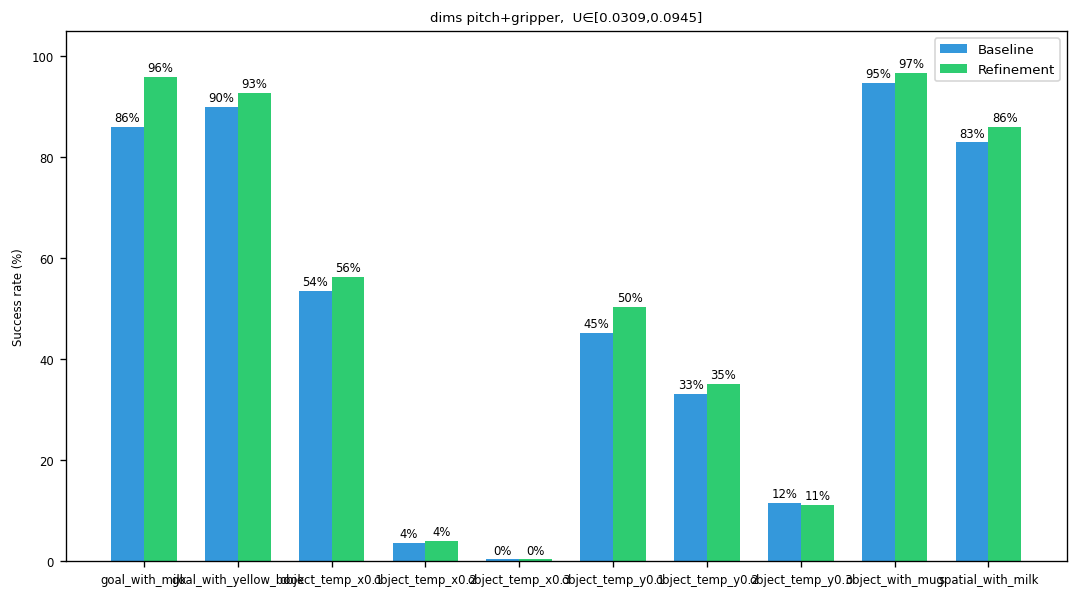

Dims pitch+gripper   U ∈ [0.0309, 0.0945]   823/2200 refined (37%)
Aggregate SR over all episodes:
  baseline (n=2200):            45.45%
  refinement @ threshold (n=823):    47.73%  (Δ +2.27 pp vs baseline)


In [ ]:
# ── Per-suite SR change for a chosen dimension subset + optional U bounds ──────
# Standalone: give it DIMS and (optional) LOWER/UPPER on the selected-dim
# uncertainty. Episodes with u_sel in [LOWER, UPPER] take the REFINED outcome;
# all others keep BASELINE. Plots per-suite baseline→policy SR change.
#
# Run after A1 (needs RESULTS_DIR, pd, np, plt). Baseline = uncertainty no-op pass.

# ── parameters ────────────────────────────────────────────────────────────────
DIMS  = ['pitch', 'gripper']   # dims used to build the uncertainty metric
LOWER = 0.0309    # lower bound on u_sel, or None
UPPER = 0.0945    # upper bound on u_sel, or None

import sqlite3, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
DB_PATH   = f'{RESULTS_DIR}/rollouts_enlarged_ppd.db'
DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']
keys      = ['suite','task_idx','episode_idx','init_state_hash']
idx = [DIM_NAMES.index(dd) for dd in DIMS]

c = sqlite3.connect(DB_PATH)
roll = pd.read_sql(
    "SELECT rollout_id, suite, task_idx, episode_idx, init_state_hash, success, "
    "pnp_enabled, pnp_mode FROM rollouts", c)
av = pd.read_sql("SELECT rollout_id, u_vec FROM pnp_action_vectors", c)
c.close()

# per-episode selected-dim uncertainty
av = av.dropna(subset=['u_vec']).copy()
av['u_arr'] = av['u_vec'].apply(lambda s: np.asarray(json.loads(s), dtype=float))
av = av[av['u_arr'].apply(lambda a: a.shape == (len(DIM_NAMES),))]
per_roll = (av.groupby('rollout_id')['u_arr']
            .apply(lambda g: np.mean(np.stack(g.values), axis=0)).reset_index())
per_roll['u_sel'] = per_roll['u_arr'].apply(lambda a: float(np.mean(a[idx])))

unc = roll[(roll.pnp_enabled==1)&(roll.pnp_mode=='uncertainty')]\
        .merge(per_roll[['rollout_id','u_sel']], on='rollout_id', how='inner')
base = unc[keys+['success']].rename(columns={'success':'base_success'}).drop_duplicates(keys)
uwin = unc[keys+['u_sel']].drop_duplicates(keys)
ref  = roll[(roll.pnp_enabled==1)&(roll.pnp_mode=='both')][keys+['success']]\
        .rename(columns={'success':'ref_success'}).drop_duplicates(keys)

paired = base.merge(uwin, on=keys, how='inner').merge(ref, on=keys, how='inner')
if len(paired)==0:
    raise SystemExit('Empty pairing — passes do not share init_state_hash/seeds, or no u_vec rows.')

# selective policy: refine iff u_sel in [LOWER, UPPER]
inw = pd.Series(True, index=paired.index)
if LOWER is not None: inw &= paired.u_sel >= LOWER
if UPPER is not None: inw &= paired.u_sel <= UPPER
paired['in_window']      = inw
paired['policy_success'] = np.where(inw, paired.ref_success, paired.base_success)

lo_s = f'{LOWER:.4f}' if LOWER is not None else '-inf'
hi_s = f'{UPPER:.4f}' if UPPER is not None else '+inf'

# per-suite baseline vs. selective-refinement SR (A2 format)
suites  = sorted(paired.suite.unique())
sr_base = paired.groupby('suite').base_success.mean().reindex(suites).fillna(0)
sr_pol  = paired.groupby('suite').policy_success.mean().reindex(suites).fillna(0)

x = np.arange(len(suites)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b2 = ax.bar(x - w/2, sr_base * 100, width=w, label='Baseline',   color='#3498db')
b3 = ax.bar(x + w/2, sr_pol  * 100, width=w, label='Refinement', color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=0, ha='center')
ax.set_ylabel('Success rate (%)')
ax.set_ylim(0, 105)
ax.set_title(f'dims {"+".join(DIMS)},  U∈[{lo_s},{hi_s}]', fontsize=8)
ax.legend(fontsize=8)
for bars_patch, vals in [(b2, sr_base), (b3, sr_pol)]:
    for bar, v in zip(bars_patch, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v*100:.0f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

# ── aggregate success-rate change across all episodes (A2 format) ──
base_sr = paired.base_success.mean()
pol_sr  = paired.policy_success.mean()
n_ref   = int(inw.sum())
print(f'Dims {"+".join(DIMS)}   U ∈ [{lo_s}, {hi_s}]   '
      f'{n_ref}/{len(paired)} refined ({inw.mean():.0%})')
print(f'Aggregate SR over all episodes:')
print(f'  baseline (n={len(paired)}):            {base_sr*100:.2f}%')
print(f'  refinement @ threshold (n={n_ref}):    {pol_sr*100:.2f}%  '
      f'(Δ {(pol_sr-base_sr)*100:+.2f} pp vs baseline)')

Sweep subsets of [x, y, z, gripper] and return the ordering of top-1 windows for SR change

In [ ]:
# ── Sweep ALL subsets of a dimension pool; rank by best single-window SR change ─
# For each non-empty subset of POOL, rebuild per-episode uncertainty from just those
# dims, sweep [lower,upper] windows (selective policy: refine in-window, baseline
# out-window), and record that subset's BEST top-1 whole-dataset SR change. Then
# order all subsets by that value.
#
# CAVEAT: this maximizes over (subset × window), so the winning number is an oracle /
# existence check, not a deployable gain. N_ref shows how thin each winning window is.
#
# Run after A1 (needs RESULTS_DIR, pd, np). Baseline = uncertainty no-op pass.

# ── parameters ────────────────────────────────────────────────────────────────
POOL          = ['x', 'y', 'z', 'gripper', 'roll', 'pitch', 'yaw']   # sweep every non-empty subset of these
N_GRID        = 25          # quantile-grid resolution per axis (per subset)
MIN_IN_WINDOW = 20          # min refined episodes for a window to count
from itertools import combinations
import sqlite3, json, numpy as np, pandas as pd
DB_PATH   = f'{RESULTS_DIR}/rollouts_enlarged_ppd.db'
DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']
keys      = ['suite','task_idx','episode_idx','init_state_hash']

# ── load once ─────────────────────────────────────────────────────────────────
c = sqlite3.connect(DB_PATH)
roll = pd.read_sql(
    "SELECT rollout_id, suite, task_idx, episode_idx, init_state_hash, success, "
    "pnp_enabled, pnp_mode FROM rollouts", c)
av = pd.read_sql("SELECT rollout_id, u_vec FROM pnp_action_vectors", c)
c.close()

av = av.dropna(subset=['u_vec']).copy()
av['u_arr'] = av['u_vec'].apply(lambda s: np.asarray(json.loads(s), dtype=float))
av = av[av['u_arr'].apply(lambda a: a.shape == (len(DIM_NAMES),))]
# mean u_vec per rollout -> a single (7,) vector, so subset means are cheap later
per_roll = (av.groupby('rollout_id')['u_arr']
            .apply(lambda g: np.mean(np.stack(g.values), axis=0)).reset_index())
u_mat = np.stack(per_roll['u_arr'].values)                     # (R, 7)
rid_to_row = {r: i for i, r in enumerate(per_roll['rollout_id'])}

unc = roll[(roll.pnp_enabled==1)&(roll.pnp_mode=='uncertainty')].copy()
ref = roll[(roll.pnp_enabled==1)&(roll.pnp_mode=='both')][keys+['success']]\
        .rename(columns={'success':'ref_success'}).drop_duplicates(keys)
unc = unc[unc.rollout_id.isin(rid_to_row)].copy()
unc['_row'] = unc.rollout_id.map(rid_to_row)
base = unc[keys+['success']].rename(columns={'success':'base_success'}).drop_duplicates(keys)

# paired frame carries the u_vec row-index so each subset just re-averages columns
paired = (unc[keys+['_row','success']].rename(columns={'success':'unc_success'})
          .drop_duplicates(keys)
          .merge(base, on=keys, how='inner')
          .merge(ref,  on=keys, how='inner'))
if len(paired)==0:
    raise SystemExit('Empty pairing — passes do not share init_state_hash/seeds, or no u_vec rows.')
total_n = len(paired); overall_base_sr = paired.base_success.mean()
rows_idx = paired['_row'].values
ref_succ = paired.ref_success.values.astype(float)
base_succ = paired.base_success.values.astype(float)
base_total = base_succ.sum()
print(f'Paired episodes: {total_n}   whole-dataset baseline SR: {overall_base_sr:.3f}')
print(f'Pool: {POOL}  → {2**len(POOL)-1} non-empty subsets\n')

def best_window(u_sel):
    """Return two (sr_change, lo, hi, n_ref) tuples: the unconstrained best, and the
    best STRICTLY-SELECTIVE window (n_ref < total_n, i.e. not 'refine everything').
    Either may be None."""
    qs = np.unique(np.quantile(u_sel, np.linspace(0,1,N_GRID)))
    best = None; best_sel = None
    for i, lo in enumerate(qs):
        for hi in qs[i:]:
            if hi <= lo: continue
            inw = (u_sel >= lo) & (u_sel <= hi)
            n_ref = int(inw.sum())
            if n_ref < MIN_IN_WINDOW: continue
            succ_in  = ref_succ[inw].sum()
            policy_sr = (succ_in + (base_total - base_succ[inw].sum())) / total_n
            chg = policy_sr - overall_base_sr
            cand = (chg, float(lo), float(hi), n_ref)
            if best is None or chg > best[0]:
                best = cand
            if n_ref < total_n and (best_sel is None or chg > best_sel[0]):
                best_sel = cand
    return best, best_sel

# ── evaluate every non-empty subset ───────────────────────────────────────────
results=[]
for k in range(1, len(POOL)+1):
    for subset in combinations(POOL, k):
        idx = [DIM_NAMES.index(dd) for dd in subset]
        u_sel = u_mat[rows_idx][:, idx].mean(axis=1)
        bw, bw_sel = best_window(u_sel)
        row = {'subset':'+'.join(subset),'n_dims':k,
               'best_sr_change':np.nan,'lo':np.nan,'hi':np.nan,'n_ref':0,
               'sel_sr_change':np.nan,'sel_lo':np.nan,'sel_hi':np.nan,'sel_n_ref':0}
        if bw is not None:
            row.update(best_sr_change=bw[0], lo=bw[1], hi=bw[2], n_ref=bw[3])
        if bw_sel is not None:
            row.update(sel_sr_change=bw_sel[0], sel_lo=bw_sel[1], sel_hi=bw_sel[2], sel_n_ref=bw_sel[3])
        results.append(row)

res = pd.DataFrame(results).sort_values('best_sr_change', ascending=False).reset_index(drop=True)

# ── ordered report ────────────────────────────────────────────────────────────
print(f'Subsets ordered by BEST single-window whole-dataset SR change '
      f'(baseline {overall_base_sr:.3f}):\n')
hdr=(f'{"rank":>4} {"subset":<14} {"nD":>3} {"bestΔSR":>8} {"N_ref":>6}   '
     f'{"selΔSR":>8} {"sel window [lo, hi]":>24} {"selN":>6}')
print(hdr); print('-'*len(hdr))
for i,r in res.iterrows():
    chg = f'{r.best_sr_change:+.3f}' if not np.isnan(r.best_sr_change) else 'n/a'
    if not np.isnan(r.sel_sr_change):
        selc = f'{r.sel_sr_change:+.3f}'; selw = f'[{r.sel_lo:.4f}, {r.sel_hi:.4f}]'; seln=f'{r.sel_n_ref:.0f}'
    else:
        selc, selw, seln = 'n/a', '—', '0'
    print(f'{i+1:>4} {r.subset:<14} {r.n_dims:>3} {chg:>8} {r.n_ref:>6.0f}   '
          f'{selc:>8} {selw:>24} {seln:>6}')

print(f'\nBest subset (unconstrained): {res.iloc[0].subset}  '
      f'(ΔSR {res.iloc[0].best_sr_change:+.3f}, N_ref={res.iloc[0].n_ref:.0f})')
sel_sorted = res.dropna(subset=['sel_sr_change']).sort_values('sel_sr_change', ascending=False)
if len(sel_sorted):
    b = sel_sorted.iloc[0]
    print(f'Best subset (strictly selective): {b.subset}  '
          f'(ΔSR {b.sel_sr_change:+.3f} at [{b.sel_lo:.4f}, {b.sel_hi:.4f}], N_ref={b.sel_n_ref:.0f})')
print('Reminder: maximized over subset × window — treat as an existence/upper-bound, '
      'not a deployable policy. Validate a fixed subset+window on held-out episodes.')
res_subset_sweep = res   # expose for downstream use

Paired episodes: 2200   whole-dataset baseline SR: 0.455
Pool: ['x', 'y', 'z', 'gripper', 'roll', 'pitch', 'yaw']  → 127 non-empty subsets

Subsets ordered by BEST single-window whole-dataset SR change (baseline 0.455):

rank subset          nD  bestΔSR  N_ref     selΔSR      sel window [lo, hi]   selN
----------------------------------------------------------------------------------
   1 gripper+pitch    2   +0.023    825     +0.023         [0.0309, 0.0945]    825
   2 x+y+gripper+pitch+yaw   5   +0.023    734     +0.023         [0.0277, 0.0709]    734
   3 x+gripper+pitch+yaw   4   +0.023    459     +0.023         [0.0327, 0.0724]    459
   4 z+gripper+roll+pitch   4   +0.022    825     +0.022         [0.0312, 0.0999]    825
   5 gripper+roll+pitch+yaw   4   +0.022    459     +0.022         [0.0327, 0.1137]    459
   6 pitch            1   +0.022   1008     +0.022         [0.0320, 0.1154]   1008
   7 x+gripper+pitch   3   +0.022    642     +0.022         [0.0324, 0.0840]    642
   8 

# First-Prediction PC1 Analysis

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import sqlite3, json, numpy as np
from sklearn.decomposition import PCA

pc1_succ, pc1_fail = [], []
rows = []

for key, succ, sj in sqlite3.connect(
        f'{RESULTS_DIR}/mm_cluster_samples_stratified.db').execute(
        "SELECT episode_key, success, samples_json FROM mm_samples"):
    X = np.array(json.loads(sj))
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-9)
    evr = PCA().fit(Xs).explained_variance_ratio_
    (pc1_succ if succ else pc1_fail).append(float(evr[0]))
    rows.append((bool(succ), key, evr[0], evr[:3]))
    print(f"{'S' if succ else 'F'} {key[:38]:<38} "
          f"PC1 frac={evr[0]:.2f}  top3={evr[:3].round(2)}")

all_pc1 = pc1_succ + pc1_fail
print('\n' + '='*55)
print(f'n episodes:        {len(all_pc1)} ({len(pc1_succ)} S, {len(pc1_fail)} F)')
print(f'PC1 frac range:    {min(all_pc1):.3f} – {max(all_pc1):.3f}')
print(f'PC1 frac mean:     {np.mean(all_pc1):.3f}  (S {np.mean(pc1_succ):.3f}, F {np.mean(pc1_fail):.3f})')
print(f'N samples, D dims: {X.shape[0]}, {X.shape[1]}')
# Marchenko-Pastur upper edge for noise-only: (1 + sqrt(D/N))^2 / D  (as a variance-ratio scale)
N, D = X.shape
print(f'(for the paper: N={N}, D={D})')

# ready-to-paste list for the plotting cell
print('\npc1_data = [')
for succ, key, p, _ in rows:
    print(f"    ({'1' if succ else '0'}, {p:.4f}),  # {key[:40]}")
print(']')

S libero_goal_with_yellow_book|5|6       PC1 frac=0.08  top3=[0.08 0.06 0.06]
S libero_goal_with_yellow_book|0|1       PC1 frac=0.11  top3=[0.11 0.09 0.08]
S libero_goal_with_yellow_book|9|7       PC1 frac=0.11  top3=[0.11 0.08 0.08]
F libero_goal_with_yellow_book|3|5       PC1 frac=0.10  top3=[0.1  0.06 0.06]
F libero_goal_with_yellow_book|5|7       PC1 frac=0.11  top3=[0.11 0.06 0.05]
F libero_goal_with_yellow_book|2|3       PC1 frac=0.17  top3=[0.17 0.07 0.06]
S libero_object_temp_x0.1|3|7            PC1 frac=0.10  top3=[0.1  0.08 0.07]
S libero_object_temp_x0.1|3|2            PC1 frac=0.11  top3=[0.11 0.08 0.06]
S libero_object_temp_x0.1|0|1            PC1 frac=0.11  top3=[0.11 0.07 0.06]
F libero_object_temp_x0.1|9|9            PC1 frac=0.12  top3=[0.12 0.09 0.06]
F libero_object_temp_x0.1|0|5            PC1 frac=0.09  top3=[0.09 0.07 0.07]
F libero_object_temp_x0.1|6|1            PC1 frac=0.09  top3=[0.09 0.07 0.07]
S libero_object_temp_x0.2|4|6            PC1 frac=0.10  top3=[0.

Plot per-episode PC1 Frac Values

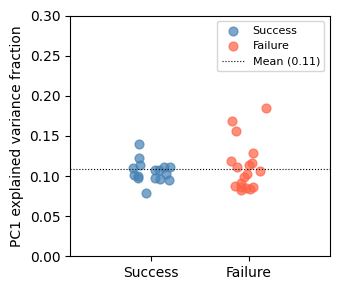

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['pdf.fonttype'] = 42   # TrueType, not Type-3
matplotlib.rcParams['ps.fonttype'] = 42

# uses `rows` from the PCA cell above: list of (success_bool, key, pc1_frac, top3)
succ = sorted(p for s, k, p, _ in rows if s)
fail = sorted(p for s, k, p, _ in rows if not s)
all_pc1 = succ + fail

fig, ax = plt.subplots(figsize=(3.5, 3))
jitter = 0.06
np.random.seed(42)
ax.scatter(np.random.uniform(-jitter, jitter, len(succ)),
           succ, color='steelblue', alpha=0.7, s=40, label='Success')
ax.scatter(0.3 + np.random.uniform(-jitter, jitter, len(fail)),
           fail, color='tomato', alpha=0.7, s=40, label='Failure')
ax.axhline(np.mean(all_pc1), color='black', linestyle=':', linewidth=0.8,
           label=f'Mean ({np.mean(all_pc1):.2f})')
ax.set_xticks([0, 0.3])
ax.set_xticklabels(['Success', 'Failure'])
ax.set_xlim(-0.25, 0.55)
ax.set_ylabel('PC1 explained variance fraction')
ax.set_ylim(0, 0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pca_isotropy.pdf', bbox_inches='tight')
plt.show()